<!-- solo-notebook -->
<a href="https://colab.research.google.com/github/amenesesy/actividad-ml-ctg/blob/main/ML_Actividad_CTG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Deteccion de anomalias y tecnicas de agrupamiento sobre el conjunto de datos CTG

**Asignatura:** Aprendizaje Automático, Maestría en Inteligencia Artificial

**Autor:** Abel Meneses Yaranga

**Repositorio del código:** https://github.com/amenesesy/actividad-ml-ctg

## Resumen

Este cuaderno desarrolla el flujo de aprendizaje no supervisado que solicita la
actividad sobre el conjunto de datos de cardiotocografía: 2 126 registros de
monitoreo fetal descritos por 21 variables que un sistema informático extrae de
los trazados de frecuencia cardiaca fetal y de actividad uterina.

Las secciones 1 y 2 cubren la carga, el diccionario de variables y el análisis
exploratorio. La 3 diagnostica los valores faltantes y justifica la decisión con
un experimento controlado. La 4 prepara la matriz de características. La 5
aplica cinco técnicas de detección de anomalías y la 6, tres de agrupamiento.
Las secciones 7 y 8 comparan los modelos y recogen las conclusiones.

Una precisión metodológica que condiciona todo lo demás: el conjunto incluye dos
variables de diagnóstico, `CLASS` y `NSP`, etiquetadas por obstetras, y ninguna
se usa para ajustar modelo alguno. Se reservan como verdad de referencia externa
para comprobar después si las anomalías y los grupos hallados tienen sentido
clínico. Esa separación es la que permite afirmar que los resultados no son un
artefacto del procedimiento.

El código, las figuras y el informe están en el repositorio público
https://github.com/amenesesy/actividad-ml-ctg; el distintivo que encabeza esta
página abre el cuaderno en Google Colab.

# 0. Configuración del entorno

El cuaderno se ejecuta sin cambios en local o en Google Colab. La primera celda
detecta el entorno, instala las librerías que falten y descarga el conjunto de
datos desde el repositorio del trabajo; la ejecución completa tarda unos dos
minutos.

La segunda reúne las librerías y fija la semilla aleatoria, detalle que no es
menor: Isolation Forest, K-Means y el experimento de imputación son estocásticos
y sin semilla fija darían cifras distintas en cada ejecución, con lo que ninguna
conclusión sería verificable.

In [1]:
# Celda 0.1. Preparacion del entorno y compatibilidad con Google Colab.
# Objetivo: que el cuaderno se ejecute igual en local que en Colab. Se detecta
#   el entorno, se instalan las librerias que falten y se descarga el conjunto
#   de datos del repositorio publico si no esta presente en el directorio.
# Salidas: la constante EN_COLAB y el archivo CTG.csv disponible en el disco.

import importlib.util
import pathlib
import subprocess
import sys
import urllib.request

# Deteccion del entorno. En Colab existe el paquete google.colab; fuera de
# Colab ni siquiera existe el paquete contenedor google, asi que la deteccion
# se hace con un import protegido y no con find_spec, que ahi fallaria.
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# Direccion base del repositorio publico del trabajo, desde donde se descargan
# los datos cuando el cuaderno se abre en un entorno recien creado.
REPO = "https://raw.githubusercontent.com/amenesesy/actividad-ml-ctg/main"

# Dependencias del cuaderno, como pares (modulo que se importa, paquete de pip).
DEPENDENCIAS = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
    ("scipy", "scipy"),
]

faltantes = [pip for modulo, pip in DEPENDENCIAS
             if importlib.util.find_spec(modulo) is None]
if faltantes:
    print("Instalando dependencias que faltan:", ", ".join(faltantes))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltantes],
                   check=True)
else:
    print("Todas las dependencias estan disponibles.")

# El conjunto de datos se descarga solo si no esta ya en el directorio actual.
if not pathlib.Path("CTG.csv").exists():
    print("Descargando CTG.csv desde el repositorio del trabajo...")
    urllib.request.urlretrieve(REPO + "/CTG.csv", "CTG.csv")

print("Entorno de ejecucion:", "Google Colab" if EN_COLAB else "instalacion local")
print("Version de Python   :", sys.version.split()[0])
print("Conjunto de datos   :", "CTG.csv disponible"
      if pathlib.Path("CTG.csv").exists() else "NO disponible")

Todas las dependencias estan disponibles.
Entorno de ejecucion: instalacion local
Version de Python   : 3.14.0
Conjunto de datos   : CTG.csv disponible


In [2]:
# Celda 0.2. Importacion de librerias y configuracion global.
# Objetivo: cargar todas las dependencias en un unico lugar, fijar la semilla
#   aleatoria y homogeneizar el estilo de los graficos.
# Salidas: las constantes globales SEMILLA y DIR_FIGURAS, y el diccionario RES
#   en el que cada seccion va depositando sus resultados numericos.

# Utilidades del sistema
import json                      # serializacion de los resultados a disco
import pathlib                   # manejo de rutas independiente del sistema
import warnings                  # control de avisos no criticos

# Manipulacion de datos
import numpy as np               # algebra vectorial y generacion aleatoria
import pandas as pd              # estructuras tabulares (DataFrame)

# Visualizacion
import matplotlib.pyplot as plt  # motor de graficos de bajo nivel
import seaborn as sns            # graficos estadisticos de alto nivel

# Preprocesamiento
from sklearn.preprocessing import StandardScaler      # z = (x - mu) / sigma
from sklearn.impute import SimpleImputer, KNNImputer  # estrategias de imputacion

# Deteccion de anomalias
from sklearn.ensemble import IsolationForest          # aislamiento por particiones
from sklearn.neighbors import LocalOutlierFactor      # densidad local relativa
from sklearn.covariance import MinCovDet              # covarianza robusta (MCD)

# Agrupamiento
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Reduccion de dimensionalidad, vecindades y metricas
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,             # cohesion frente a separacion (validacion interna)
    silhouette_samples,           # silueta calculada por observacion
    davies_bouldin_score,         # razon dispersion/separacion (menor es mejor)
    calinski_harabasz_score,      # razon de varianzas entre/intra (mayor es mejor)
    adjusted_rand_score,          # concordancia con etiquetas (validacion externa)
    normalized_mutual_info_score, # informacion mutua normalizada
)
from scipy import stats           # pruebas estadisticas (Kolmogorov-Smirnov, chi2)

# Configuracion global del cuaderno
SEMILLA = 42                                  # unica fuente de aleatoriedad
np.random.seed(SEMILLA)
warnings.filterwarnings("ignore")             # silencia avisos de version
pd.set_option("display.width", 140)           # ancho de impresion de los DataFrame
pd.set_option("display.max_columns", 50)

# Paleta institucional, tomada de la plantilla Word de la actividad: el cian
# corporativo, los dos grises del texto y del pie, y dos tonos de apoyo para las
# escalas de gravedad clinica.
UNIR_CIAN = "#0098CD"      # color corporativo
UNIR_CIAN_OSC = "#006E96"  # variante oscura, para segundas series
UNIR_CIAN_CLA = "#7FD0EC"  # variante clara
UNIR_GRIS = "#777777"      # gris del pie de pagina
UNIR_GRIS_OSC = "#333333"  # color del texto normal
UNIR_AMBAR = "#E8A33D"     # nivel intermedio en las escalas de gravedad
UNIR_ROJO = "#C1272D"      # nivel alto en las escalas de gravedad

PALETA_UNIR = [UNIR_CIAN, UNIR_ROJO, UNIR_GRIS, UNIR_CIAN_OSC, UNIR_AMBAR,
               UNIR_GRIS_OSC, UNIR_CIAN_CLA]

# Mapas de color derivados de la misma paleta. El divergente se usa en las
# matrices de correlacion y de centroides; el secuencial, en la matriz de
# concordancia entre detectores.
from matplotlib.colors import LinearSegmentedColormap
CMAP_DIV = LinearSegmentedColormap.from_list(
    "unir_div", [UNIR_CIAN_OSC, UNIR_CIAN, "#FFFFFF", "#E38B8E", UNIR_ROJO])
CMAP_SEQ = LinearSegmentedColormap.from_list(
    "unir_seq", ["#FFFFFF", UNIR_CIAN_CLA, UNIR_CIAN, UNIR_CIAN_OSC])

sns.set_theme(style="whitegrid", palette=PALETA_UNIR)   # estilo institucional
plt.rcParams["text.color"] = UNIR_GRIS_OSC
plt.rcParams["axes.labelcolor"] = UNIR_GRIS_OSC
plt.rcParams["axes.titlecolor"] = UNIR_GRIS_OSC
plt.rcParams["xtick.color"] = UNIR_GRIS_OSC
plt.rcParams["ytick.color"] = UNIR_GRIS_OSC
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200      # resolucion suficiente para imprimir
plt.rcParams["savefig.bbox"] = "tight"
# Tipografia holgada dentro de las figuras. Las figuras se disenan compactas y
# con letra grande para que sigan siendo legibles cuando el informe en PDF las
# reduce al ancho de la caja de texto.
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

DIR_FIGURAS = pathlib.Path("figuras")         # carpeta destino de las figuras
DIR_FIGURAS.mkdir(exist_ok=True)

# Diccionario acumulador. Cada seccion deposita aqui sus resultados numericos
# para que el informe en PDF se construya despues a partir de datos reales y no
# de cifras transcritas a mano.
RES = {}


def guardar(nombre):
    """Guarda la figura activa de matplotlib en figuras/<nombre>.png y la muestra.

    Parametros
    ----------
    nombre : str
        Nombre del archivo destino, sin extension ni ruta.
    """
    plt.savefig(DIR_FIGURAS / (nombre + ".png"))
    plt.show()


print("Librerias cargadas correctamente. Semilla aleatoria fijada en", SEMILLA)

Librerias cargadas correctamente. Semilla aleatoria fijada en 42


# 1. El conjunto de datos

## 1.1 Contexto del problema

La cardiotocografía registra a la vez la frecuencia cardiaca del feto y la
actividad contráctil del útero durante el embarazo tardío y el parto. Su
interpretación visual tiene una concordancia entre observadores notoriamente
baja, y por eso desde los años noventa existen sistemas que resumen cada trazado
en un vector de descriptores numéricos.

El archivo `CTG.csv` es el resultado de aplicar el sistema SisPorto 2.0
(Ayres-de-Campos et al., 2000) a 2 126 trazados: cada fila es un segmento de
registro y cada columna un descriptor automático. Tres obstetras etiquetaron
además cada segmento con `CLASS`, el patrón morfológico en diez categorías, y
`NSP`, el estado fetal en tres niveles: normal, sospechoso y patológico.

## 1.2 Por qué este conjunto se ajusta a la actividad

El problema encaja con las dos técnicas que pide el enunciado. Los casos
patológicos son minoritarios, apenas el 8,3 % del total, de modo que un buen
detector de atípicos debería enriquecerse en ellos sin haberlos visto nunca: eso
permite medir de forma objetiva si resulta útil y no solo si es matemáticamente
correcto. Y si la frecuencia cardiaca fetal presenta patrones morfológicos
diferenciados, un algoritmo de agrupamiento debería recuperarlos al menos en
parte; el contraste posterior con `NSP` cuantifica cuánta de esa estructura es
real y cuánta un artefacto del algoritmo.

In [3]:
# Celda 1.1. Carga del conjunto de datos.
# Se usa la copia local que dejo preparada la celda 0.1 y, si por lo que fuera
# no estuviera, se recurre al archivo original publicado por el curso.
# Salidas: df_bruto, con los datos tal y como vienen del archivo.

RUTA_LOCAL = pathlib.Path("CTG.csv")
URL_CURSO = ("https://raw.githubusercontent.com/OscarJimenezFlores/ML/"
             "refs/heads/main/Data/CTG.csv")

origen = RUTA_LOCAL if RUTA_LOCAL.exists() else URL_CURSO
df_bruto = pd.read_csv(origen)

print("Origen de los datos          :", origen)
print("Dimensiones (filas, columnas):", df_bruto.shape)
print("\nPrimeras 3 filas:")
df_bruto.head(3)

Origen de los datos          : CTG.csv
Dimensiones (filas, columnas): (2129, 40)

Primeras 3 filas:


,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,DR,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,0.0,0.0,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


Antes de calcular ningún estadístico conviene documentar qué significa cada
columna y qué papel juega. Sin ese paso el análisis se vuelve estadística ciega:
no hay forma de decidir qué variables son informativas, cuáles simples
identificadores, cuáles duplican información y cuáles son etiquetas que deben
quedar apartadas del modelado.

In [4]:
# Celda 1.2. Diccionario de variables.
# Documenta el significado y el rol de cada una de las 40 columnas del archivo.
# Salidas: el diccionario DICCIONARIO y la tabla legible tabla_dic.

DICCIONARIO = {
    # Identificadores del registro, sin valor descriptivo
    "FileName": ("Identificador", "Nombre del archivo del trazado original"),
    "Date":     ("Identificador", "Fecha del registro"),
    "SegFile":  ("Identificador", "Nombre del segmento analizado"),
    "b":        ("Identificador", "Indice de inicio del segmento en el trazado"),
    "e":        ("Identificador", "Indice de fin del segmento en el trazado"),
    # Descriptores de la frecuencia cardiaca fetal
    "LBE":      ("Redundante",    "Linea de base de la FCF segun el experto medico"),
    "LB":       ("Numerica",      "Linea de base de la FCF calculada por SisPorto (lpm)"),
    "AC":       ("Numerica",      "Numero de aceleraciones"),
    "FM":       ("Numerica",      "Numero de movimientos fetales"),
    "UC":       ("Numerica",      "Numero de contracciones uterinas"),
    "ASTV":     ("Numerica",      "% de tiempo con variabilidad anormal a corto plazo"),
    "MSTV":     ("Numerica",      "Valor medio de la variabilidad a corto plazo"),
    "ALTV":     ("Numerica",      "% de tiempo con variabilidad anormal a largo plazo"),
    "MLTV":     ("Numerica",      "Valor medio de la variabilidad a largo plazo"),
    "DL":       ("Numerica",      "Numero de deceleraciones ligeras"),
    "DS":       ("Numerica",      "Numero de deceleraciones severas"),
    "DP":       ("Numerica",      "Numero de deceleraciones prolongadas"),
    "DR":       ("Constante",     "Numero de deceleraciones repetitivas (siempre 0)"),
    # Descriptores del histograma de la frecuencia cardiaca fetal
    "Width":    ("Numerica",      "Amplitud del histograma de la FCF"),
    "Min":      ("Numerica",      "Valor minimo del histograma"),
    "Max":      ("Numerica",      "Valor maximo del histograma"),
    "Nmax":     ("Numerica",      "Numero de picos del histograma"),
    "Nzeros":   ("Numerica",      "Numero de ceros del histograma"),
    "Mode":     ("Numerica",      "Moda del histograma"),
    "Mean":     ("Numerica",      "Media del histograma"),
    "Median":   ("Numerica",      "Mediana del histograma"),
    "Variance": ("Numerica",      "Varianza del histograma"),
    "Tendency": ("Ordinal",       "Tendencia del histograma (-1 izq., 0 simetrica, 1 der.)"),
    # Codificacion disyuntiva (one-hot) de la etiqueta CLASS
    **{c: ("One-hot de CLASS", "Indicador binario del patron morfologico " + c)
       for c in ["A", "B", "C", "D", "E", "AD", "DE", "LD", "FS", "SUSP"]},
    # Etiquetas de diagnostico, reservadas como verdad de referencia
    "CLASS":    ("Etiqueta", "Patron morfologico de la FCF (10 categorias)"),
    "NSP":      ("Etiqueta", "Estado fetal: 1=Normal, 2=Sospechoso, 3=Patologico"),
}

tabla_dic = pd.DataFrame(
    [(v, r, d) for v, (r, d) in DICCIONARIO.items()],
    columns=["Variable", "Rol", "Descripcion"],
)

print("Columnas documentadas:", len(tabla_dic), "| reparto por rol:")
for rol, n in tabla_dic["Rol"].value_counts().items():
    ejemplos = ", ".join(tabla_dic.loc[tabla_dic["Rol"] == rol, "Variable"].head(4))
    print("  %-18s %2d   (%s%s)" % (rol, n, ejemplos, ", ..." if n > 4 else ""))

RES["n_columnas"] = int(df_bruto.shape[1])

Columnas documentadas: 40 | reparto por rol:
  Numerica           20   (LB, AC, FM, UC, ...)
  One-hot de CLASS   10   (A, B, C, D, ...)
  Identificador       5   (FileName, Date, SegFile, b, ...)
  Etiqueta            2   (CLASS, NSP)
  Redundante          1   (LBE)
  Constante           1   (DR)
  Ordinal             1   (Tendency)


El reparto por rol deja ver que el archivo contiene menos información de la que
sugieren sus 40 columnas: cinco identifican el registro, una duplica a otra, otra
es constante, diez recodifican la etiqueta `CLASS` y dos son las propias
etiquetas. Solo veintiuna describen el trazado, y en la sección 4 se verá que
incluso entre esas hay una redundancia exacta.

# 2. Análisis descriptivo de los datos

El análisis exploratorio persigue tres objetivos antes de aplicar ningún
algoritmo: conocer la escala y la forma de cada variable, porque la detección de
anomalías y el agrupamiento se basan en distancias y son sensibles a las unidades
y a la asimetría; detectar los problemas de calidad, es decir, filas espurias,
columnas constantes, duplicados y redundancias que contaminarían los modelos; y
cuantificar la redundancia mediante la matriz de correlaciones, dato decisivo
para saber si conviene reducir la dimensionalidad.

## 2.1 Estructura del conjunto

In [5]:
# Celda 2.1. Estructura general del conjunto de datos.
# Objetivo: inspeccionar dimensiones, tipos de dato, memoria y duplicados. Es el
#   primer control de calidad, y cualquier anomalia estructural debe detectarse
#   aqui y no cuando ya estan fallando los modelos.

print("Dimensiones: %d filas x %d columnas (%.1f KB)"
      % (df_bruto.shape[0], df_bruto.shape[1],
         df_bruto.memory_usage(deep=True).sum() / 1024))

# Reparto de tipos de dato y filas repetidas. Un duplicado exacto en un conjunto
# de senales clinicas seria sospechoso de un error de exportacion.
tipos = ", ".join("%s=%d" % (t, n) for t, n in df_bruto.dtypes.value_counts().items())
print("Tipos de dato:", tipos)
print("Filas exactamente duplicadas:", int(df_bruto.duplicated().sum()))

# Ultimas filas del archivo: es donde suelen aparecer los artefactos de las
# hojas de calculo originales, como filas de resumen o separadores en blanco.
print("\nUltimas 4 filas del archivo (columnas 8 a 17):")
print(df_bruto.iloc[-4:, 8:18].to_string())

Dimensiones: 2129 filas x 40 columnas (985.9 KB)
Tipos de dato: float64=37, str=3
Filas exactamente duplicadas: 0

Ultimas 4 filas del archivo (columnas 8 a 17):
         FM    UC  ASTV  MSTV  ALTV  MLTV    DL   DS   DP   DR
2125    1.0   5.0  74.0   0.4  36.0   5.0   0.0  0.0  0.0  0.0
2126    NaN   NaN   NaN   NaN   NaN   NaN   NaN  NaN  NaN  NaN
2127    NaN   NaN   NaN   NaN   NaN   NaN   0.0  0.0  0.0  0.0
2128  564.0  23.0  87.0   7.0  91.0  50.7  16.0  1.0  4.0  0.0


La inspección de las últimas filas revela el primer hallazgo del trabajo: el
archivo no termina en un registro clínico. Las tres últimas líneas son residuos
de la hoja de cálculo original `CTG.xls`, una vacía, otra con ceros y una tercera
que repite el valor máximo de cada columna. No son pacientes, sino las filas de
resumen que la hoja dejó al pie, y son exactamente las que generan todos los
valores faltantes del conjunto.

## 2.2 Estadísticos descriptivos de las variables numéricas

In [6]:
# Celda 2.2. Estadisticos descriptivos de las variables numericas.
# Objetivo: obtener tendencia central, dispersion y forma de cada variable. A
#   los descriptivos clasicos se anaden la asimetria y la curtosis, que son las
#   medidas que anticipan como se comportaran los detectores de anomalias
#   basados en la hipotesis de normalidad.
# Salidas: el DataFrame desc, con una fila por variable.

# Se excluyen las columnas de texto; el resto son numericas.
num_bruto = df_bruto.select_dtypes(include=[np.number])

# describe() entrega conteo, media, desviacion, minimo, cuartiles y maximo.
desc = num_bruto.describe().T

# Asimetria: 0 indica simetria; un valor absoluto mayor que 1 indica cola marcada.
desc["asimetria"] = num_bruto.skew()
# Curtosis de Fisher: 0 es la normal; por encima de 3 hay colas muy pesadas.
desc["curtosis"] = num_bruto.kurtosis()
# Coeficiente de variacion: dispersion relativa, comparable entre variables.
desc["cv"] = desc["std"] / desc["mean"].replace(0, np.nan)

desc = desc.round(2)

# Los descriptivos se calculan para las 37 columnas numericas, pero se imprime
# una seleccion de doce que cubre los tres aspectos que se comentan despues: el
# conteo irregular, la disparidad de escalas y la asimetria de los conteos.
SELECCION = ["LB", "AC", "ASTV", "MSTV", "ALTV", "MLTV",
             "DS", "DP", "Width", "Mean", "Variance", "Nzeros"]
print("Descriptivos de 12 de las %d variables numericas:\n" % desc.shape[0])
print(desc.loc[SELECCION,
               ["count", "mean", "std", "min", "max", "asimetria", "curtosis"]].to_string())

# Se guardan las variables mas asimetricas, que son las que mas condicionan la
# eleccion del metodo de deteccion de anomalias.
RES["top_asimetria"] = desc["asimetria"].abs().sort_values(ascending=False).head(6).round(2).to_dict()

Descriptivos de 12 de las 37 variables numericas:

           count    mean    std    min    max  asimetria  curtosis
LB        2126.0  133.30   9.84  106.0  160.0       0.02     -0.29
AC        2126.0    2.72   3.56    0.0   26.0       1.66      3.12
ASTV      2127.0   47.01  17.21   12.0   87.0      -0.01     -1.05
MSTV      2127.0    1.34   0.89    0.2    7.0       1.72      5.16
ALTV      2127.0    9.88  18.48    0.0   91.0       2.20      4.28
MLTV      2127.0    8.21   5.70    0.0   50.7       1.47      5.20
DS        2128.0    0.00   0.06    0.0    1.0      16.23    261.62
DP        2128.0    0.13   0.47    0.0    4.0       4.29     19.93
Width     2126.0   70.45  38.96    3.0  180.0       0.31     -0.90
Mean      2126.0  134.61  15.59   73.0  182.0      -0.65      0.93
Variance  2126.0   18.81  28.98    0.0  269.0       3.22     15.13
Nzeros    2126.0    0.32   0.71    0.0   10.0       3.92     30.37


La tabla admite tres lecturas. La columna `count` no es constante: la mayoría de
variables tiene 2 126 observaciones válidas y unas pocas 2 127 o 2 128, huella de
las filas de resumen detectadas antes.

Las escalas son radicalmente distintas: `LB` se mueve en torno a 133 latidos por
minuto, `MSTV` en torno a 1,3 y `Variance` alcanza 269. Cualquier algoritmo
basado en la distancia euclídea quedaría dominado por las variables de rango
grande, de modo que la estandarización es imprescindible, cuestión que se retoma
en la sección 4.

La tercera lectura es la forma de las distribuciones. Variables como `DS`, `DP`,
`Variance` o `Nzeros` presentan asimetrías muy superiores a 1 y curtosis
elevadas, porque son conteos de eventos raros con enorme acumulación de ceros.
Esto anticipa que los métodos que asumen normalidad, como el Z-score o la
distancia de Mahalanobis, marcarán muchos falsos positivos, y favorece a los no
paramétricos.

## 2.3 Variables categóricas y frecuencias

In [7]:
# Celda 2.3. Variables categoricas: categorias y frecuencias.
# Objetivo: listar las categorias de cada variable cualitativa y su frecuencia.
#   Se distinguen dos grupos, porque pandas solo reconoce el primero: las
#   categoricas almacenadas como texto (FileName, Date, SegFile) y las
#   codificadas como numeros (CLASS, NSP, Tendency y las diez indicadoras).
#   Tratar estas ultimas como continuas seria un error conceptual, porque la
#   media de NSP no significa nada.

# Categoricas almacenadas como texto
cat_texto = df_bruto.select_dtypes(include=["object"]).columns.tolist()
print("Categoricas de texto (cardinalidad sobre %d filas):" % len(df_bruto))
for col in cat_texto:
    n_cat = df_bruto[col].nunique()
    print("  %-9s %5d categorias distintas  (%.1f %% de las filas)"
          % (col, n_cat, 100 * n_cat / len(df_bruto)))
print("  La cardinalidad casi maxima las identifica como IDENTIFICADORES.")

# Categoricas codificadas como numeros. Tratarlas como continuas seria un error
# conceptual, porque la media de NSP no significa nada.
ETIQUETAS_NSP = {1: "Normal", 2: "Sospechoso", 3: "Patologico"}
frec_nsp = df_bruto["NSP"].value_counts(dropna=False).sort_index()
print("\nFrecuencias de NSP (estado fetal):")
for v, n in frec_nsp.items():
    print("  %-11s %5d   %5.1f %%"
          % (ETIQUETAS_NSP.get(v, "artefacto"), n, 100 * n / frec_nsp.sum()))

frec_class = df_bruto["CLASS"].value_counts().sort_values()
print("\nCLASS   : 10 patrones morfologicos, de %d a %d casos por categoria"
      % (frec_class.iloc[0], frec_class.iloc[-1]))

# Coherencia de la codificacion one-hot de CLASS
COLS_ONEHOT = ["A", "B", "C", "D", "E", "AD", "DE", "LD", "FS", "SUSP"]
suma_onehot = df_bruto[COLS_ONEHOT].sum(axis=1)
print("\nSuma por fila de las 10 indicadoras one-hot:",
      suma_onehot.value_counts(dropna=False).to_dict())
print("Constante e igual a 1: es una recodificacion EXACTA de CLASS, que no")
print("aporta informacion nueva y crea una dependencia lineal perfecta.")

RES["frec_nsp"] = df_bruto["NSP"].value_counts(dropna=False).sort_index().to_dict()

Categoricas de texto (cardinalidad sobre 2129 filas):
  FileName    352 categorias distintas  (16.5 % de las filas)
  Date         48 categorias distintas  (2.3 % de las filas)
  SegFile    2126 categorias distintas  (99.9 % de las filas)
  La cardinalidad casi maxima las identifica como IDENTIFICADORES.

Frecuencias de NSP (estado fetal):
  Normal       1655    77.7 %
  Sospechoso    295    13.9 %
  Patologico    176     8.3 %
  artefacto       3     0.1 %

CLASS   : 10 patrones morfologicos, de 53 a 579 casos por categoria



Suma por fila de las 10 indicadoras one-hot: {1.0: 2126, 0.0: 3}
Constante e igual a 1: es una recodificacion EXACTA de CLASS, que no
aporta informacion nueva y crea una dependencia lineal perfecta.


El análisis de las categóricas produce cuatro decisiones. `FileName`, `Date` y
`SegFile` tienen una cardinalidad casi igual al número de filas, lo que las
identifica como identificadores del registro y las descarta. `NSP` está muy
desbalanceada, con un 77,8 % de normales, un 13,9 % de sospechosos y un 8,3 % de
patológicos, y ese desbalance es lo que convierte al conjunto en un buen banco de
pruebas para la detección de anomalías. `CLASS` reparte los datos en diez
categorías con frecuencias de 53 a 579 casos. Y las diez indicadoras de `A` a
`SUSP` suman exactamente 1 en todas las filas, prueba de que son una codificación
disyuntiva de `CLASS`: mantenerlas duplicaría información y, peor aún, haría
singular la matriz de covarianzas, impidiendo calcular la distancia de
Mahalanobis.

## 2.4 Matriz de correlaciones

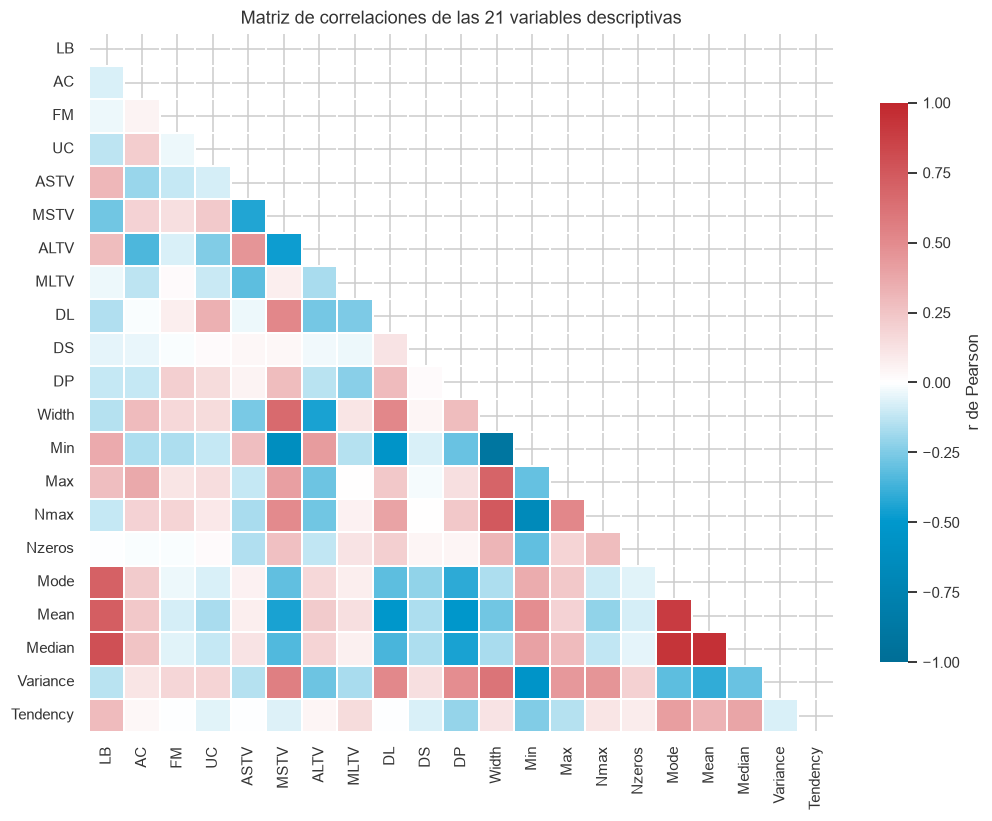

Pares de variables con |r| >= 0.70:

  Mean      y Median     r = +0.948
  Mode      y Median     r = +0.933
  Width     y Min        r = -0.899
  Mode      y Mean       r = +0.893
  LB        y Median     r = +0.789
  Width     y Nmax       r = +0.747
  LB        y Mean       r = +0.723
  LB        y Mode       r = +0.709

Correlacion absoluta media entre pares: 0.234


In [8]:
# Celda 2.4. Matriz de correlaciones entre las variables numericas.
# Objetivo: cuantificar la redundancia lineal entre descriptores. La matriz se
#   calcula solo sobre las 21 variables descriptivas reales, porque incluir los
#   identificadores, las one-hot o las etiquetas produciria correlaciones
#   espurias y una figura ilegible.
# Salidas: la figura fig_correlaciones y la lista de pares muy correlacionados.

# Variables descriptivas: se excluyen identificadores (FileName, Date, SegFile,
# b, e), la redundante LBE, la constante DR, las one-hot y las etiquetas.
VARIABLES = ["LB", "AC", "FM", "UC", "ASTV", "MSTV", "ALTV", "MLTV",
             "DL", "DS", "DP", "Width", "Min", "Max", "Nmax", "Nzeros",
             "Mode", "Mean", "Median", "Variance", "Tendency"]

# Se usan solo las filas validas; las 3 de artefacto se depuran en la seccion 3.
corr = df_bruto[VARIABLES].dropna().corr(method="pearson")

plt.figure(figsize=(9.5, 7.6))
mascara = np.triu(np.ones_like(corr, dtype=bool))   # oculta el triangulo superior
# Se representa el color sin anotar cada coeficiente: con 21 variables son
# 210 numeros que resultarian ilegibles al reducir la figura al ancho de la
# pagina. Los pares fuertes se listan a continuacion en forma de tabla.
sns.heatmap(corr, mask=mascara, annot=False, cmap=CMAP_DIV,
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            cbar_kws={"shrink": 0.8, "label": "r de Pearson"})
plt.title("Matriz de correlaciones de las 21 variables descriptivas")
plt.tight_layout()
guardar("fig_correlaciones")

# Extraccion de los pares fuertemente correlacionados. Se recorre solo el
# triangulo inferior para no repetir cada par dos veces.
pares = []
for i in range(len(VARIABLES)):
    for j in range(i + 1, len(VARIABLES)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.70:
            pares.append((VARIABLES[i], VARIABLES[j], round(float(r), 3)))
pares = sorted(pares, key=lambda t: -abs(t[2]))

print("Pares de variables con |r| >= 0.70:\n")
for a, b, r in pares:
    print("  %-9s y %-9s  r = %+.3f" % (a, b, r))

RES["pares_correlacionados"] = pares
RES["corr_media_abs"] = float(np.abs(corr.values[np.triu_indices_from(corr, k=1)]).mean().round(3))
print("\nCorrelacion absoluta media entre pares: %.3f" % RES["corr_media_abs"])

La matriz revela una redundancia clara y clínicamente interpretable. Un primer
bloque reúne `Mean`, `Median`, `Mode` y `LB`, con correlaciones de 0,71 a 0,95,
siendo `Mean` y `Median` el par más redundante: las cuatro miden dónde se sitúa
la frecuencia cardiaca y solo cambian de estimador.

Un segundo bloque agrupa los descriptores de dispersión del histograma. `Width`
correlaciona a −0,90 con `Min`, a 0,75 con `Nmax` y a 0,69 con `Max`. La relación
resulta de hecho exacta, porque `Width` es igual a `Max` menos `Min`, como se
comprobará en la sección 4; la correlación por pares no llega a revelarla porque
la dependencia involucra a tres variables.

También hay correlaciones negativas informativas: `ASTV` con `MSTV` a −0,43 y
`Variance` con `Min` a −0,55, lo que expresa que cuanto mayor es el tiempo con
variabilidad anormal, menor es la variabilidad media efectiva. La redundancia
global es moderada, con una correlación absoluta media de 0,234 concentrada en
esos dos bloques, de modo que una parte apreciable de la varianza vive en pocas
direcciones. Eso justifica recurrir al análisis de componentes principales para
visualizar y para mitigar la maldición de la dimensionalidad que sufre DBSCAN.

## 2.5 Distribuciones de las variables clave

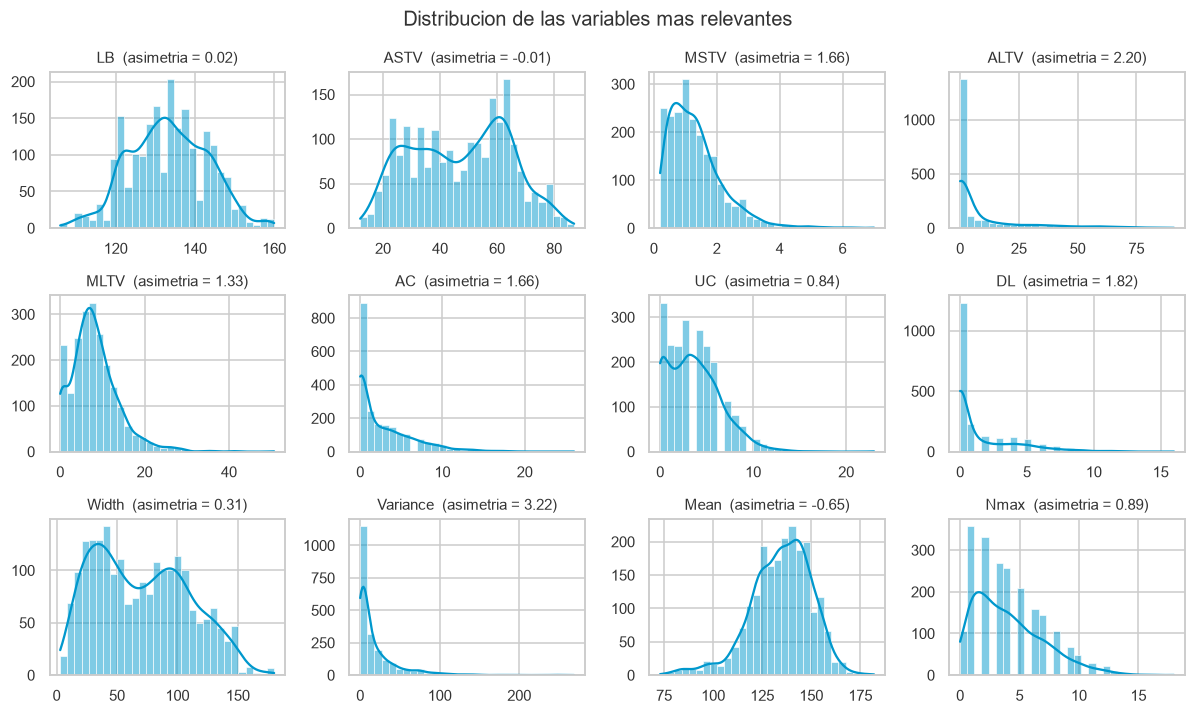

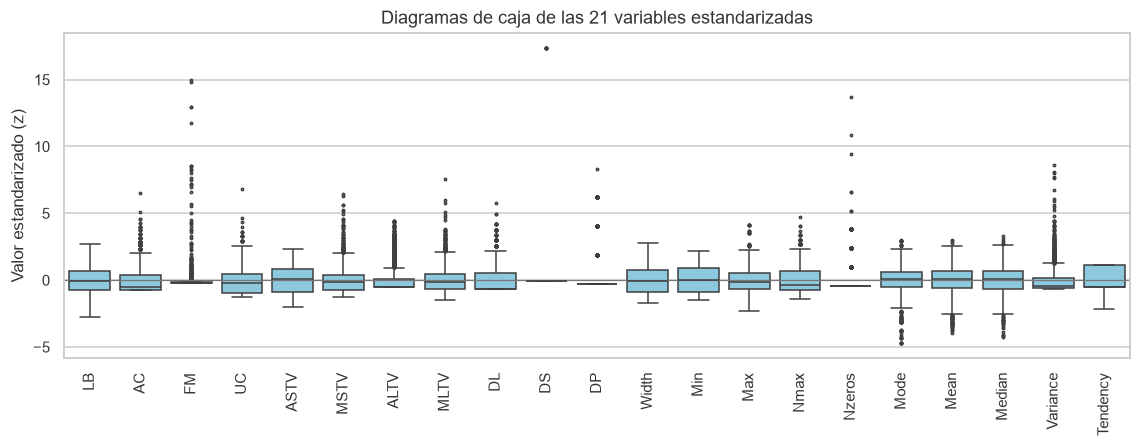

Atipicos univariantes (criterio de Tukey), 8 variables mas afectadas:
Nzeros      502
FM          310
ALTV        309
Variance    184
DP          178
AC           83
DL           81
Mode         73

Filas con algun atipico en alguna de las 21 variables: 1220 de 2126 (57.4 %)


In [9]:
# Celda 2.5. Distribucion de las variables mas relevantes.
# Objetivo: visualizar la forma de la distribucion de un subconjunto
#   representativo de variables, para confirmar graficamente la asimetria que
#   ya se detecto numericamente en la celda 2.2.
# Salidas: las figuras fig_distribuciones y fig_boxplots.

VARS_CLAVE = ["LB", "ASTV", "MSTV", "ALTV", "MLTV", "AC",
              "UC", "DL", "Width", "Variance", "Mean", "Nmax"]

datos_validos = df_bruto[VARIABLES].dropna()

# Histogramas con estimacion de densidad
fig, ejes = plt.subplots(3, 4, figsize=(11, 6.6))
for eje, col in zip(ejes.flatten(), VARS_CLAVE):
    sns.histplot(datos_validos[col], bins=30, kde=True, ax=eje, color=UNIR_CIAN)
    eje.set_title(col + "  (asimetria = %.2f)" % datos_validos[col].skew(), fontsize=10)
    eje.set_xlabel("")
    eje.set_ylabel("")
fig.suptitle("Distribucion de las variables mas relevantes", fontsize=13)
plt.tight_layout()
guardar("fig_distribuciones")

# Diagramas de caja sobre datos estandarizados. Se estandariza solo para poder
# dibujar todas las variables en un mismo eje; el objetivo es comparar la
# CANTIDAD de puntos que quedan fuera de los bigotes.
datos_z = (datos_validos - datos_validos.mean()) / datos_validos.std()

plt.figure(figsize=(10.5, 4.2))
sns.boxplot(data=datos_z, orient="v", fliersize=1.5, color=UNIR_CIAN_CLA)
plt.xticks(rotation=90)
plt.axhline(0, color=UNIR_GRIS, lw=0.8)
plt.ylabel("Valor estandarizado (z)")
plt.title("Diagramas de caja de las 21 variables estandarizadas")
plt.tight_layout()
guardar("fig_boxplots")

# Cuantificacion del numero de atipicos univariantes por variable segun la
# regla clasica de Tukey: fuera de [Q1 - 1.5*RIC, Q3 + 1.5*RIC].
q1 = datos_validos.quantile(0.25)
q3 = datos_validos.quantile(0.75)
ric = q3 - q1
atipicos_por_var = ((datos_validos < (q1 - 1.5 * ric)) | (datos_validos > (q3 + 1.5 * ric))).sum()
atipicos_por_var = atipicos_por_var.sort_values(ascending=False)

fuera = ((datos_validos < (q1 - 1.5 * ric)) | (datos_validos > (q3 + 1.5 * ric)))
print("Atipicos univariantes (criterio de Tukey), 8 variables mas afectadas:")
print(atipicos_por_var.head(8).to_string())
print("\nFilas con algun atipico en alguna de las 21 variables: %d de %d (%.1f %%)"
      % (fuera.any(axis=1).sum(), len(datos_validos),
         100 * fuera.any(axis=1).mean()))
RES["atipicos_univariantes"] = atipicos_por_var.head(8).to_dict()

Los histogramas de la figura 2 confirman lo que anticipaban la asimetría y la
curtosis: solo `LB`, `Mean`, `Mode` y `Median` son aproximadamente simétricas y
el resto están fuertemente sesgadas a la derecha, con una masa enorme de ceros en
los conteos como `DS`, `DP` o `Nzeros`.

Los diagramas de caja de la figura 3 muestran que casi todas las variables tienen
puntos fuera de los bigotes, advertencia metodológica de primer orden: aplicar
una regla univariante y eliminar toda fila con algún atípico perdería una
fracción enorme del conjunto, y serían justo los casos clínicamente más
interesantes los que desaparecerían. La detección de anomalías tiene que ser
multivariante.

# 3. Tratamiento de los valores faltantes

## 3.1 Diagnóstico

In [10]:
# Celda 3.1. Diagnostico de los valores faltantes.
# Objetivo: cuantificar los faltantes y, sobre todo, describir su PATRON. La
#   decision de imputar o eliminar depende del patron y no del recuento:
#   faltantes dispersos y faltantes concentrados en filas completas son
#   problemas distintos que admiten soluciones opuestas.
# Salidas: la serie faltantes y los indices filas_con_na.

faltantes = df_bruto.isnull().sum()

print("Celdas faltantes: %d (%.3f %% del total), en %d de %d columnas"
      % (faltantes.sum(),
         100 * faltantes.sum() / (df_bruto.shape[0] * df_bruto.shape[1]),
         (faltantes > 0).sum(), df_bruto.shape[1]))
print("Faltantes por columna: %s" % faltantes[faltantes > 0].value_counts().to_dict()
      + "  (lectura: n columnas con n faltantes)")

# Analisis del patron: se cuenta cuantos faltantes tiene CADA FILA. La decision
# de imputar o eliminar depende de aqui, no del recuento global.
na_por_fila = df_bruto.isnull().sum(axis=1)
filas_con_na = df_bruto.index[na_por_fila > 0]

print("\nFilas con al menos un faltante: %d  ->  indices %s"
      % (len(filas_con_na), list(filas_con_na)))
print("Faltantes en cada una de esas filas (sobre 40 columnas): %s"
      % na_por_fila[filas_con_na].to_dict())

print("\nContenido de esas tres filas (columnas 8 a 17):")
print(df_bruto.loc[filas_con_na].iloc[:, 8:18].to_string())

RES["faltantes_total"] = int(faltantes.sum())
RES["filas_con_na"] = [int(i) for i in filas_con_na]

Celdas faltantes: 106 (0.124 % del total), en 40 de 40 columnas
Faltantes por columna: {3: 30, 2: 6, 1: 4}  (lectura: n columnas con n faltantes)

Filas con al menos un faltante: 3  ->  indices [2126, 2127, 2128]
Faltantes en cada una de esas filas (sobre 40 columnas): {2126: 40, 2127: 36, 2128: 30}

Contenido de esas tres filas (columnas 8 a 17):
         FM    UC  ASTV  MSTV  ALTV  MLTV    DL   DS   DP   DR
2126    NaN   NaN   NaN   NaN   NaN   NaN   NaN  NaN  NaN  NaN
2127    NaN   NaN   NaN   NaN   NaN   NaN   0.0  0.0  0.0  0.0
2128  564.0  23.0  87.0   7.0  91.0  50.7  16.0  1.0  4.0  0.0


El diagnóstico es concluyente y desmonta la lectura ingenua del problema. Hay
106 celdas faltantes que afectan a las 40 columnas del archivo, pero todas ellas
se concentran en solo 3 filas, las de índice 2126, 2127 y 2128, que son las tres
últimas. Esas tres filas no son pacientes con datos incompletos: son las filas
de resumen que la hoja de cálculo original dejó al pie de la tabla. La primera
está completamente vacía. La segunda contiene ceros en `DL`, `DS`, `DP` y `DR`,
que son exactamente los mínimos de esas cuatro columnas. Y la tercera reproduce
el máximo de las diez columnas en las que tiene valor, desde `FM` igual a 564
hasta `MLTV` igual a 50,7, coincidencia que se verifica una a una en el apartado
siguiente. Ninguna de las tres tiene valor en `NSP` ni en `CLASS`, es decir,
ningún obstetra las diagnosticó, sencillamente porque no existen como
observaciones.

## 3.2 Decisión: eliminar frente a imputar

En términos de la tipología de Rubin (1976), este no es un caso de datos
faltantes completamente al azar, ni al azar, ni no al azar: no falta ningún dato,
sino que hay filas que no son observaciones. La discusión sobre la media, la
mediana o la moda solo es pertinente cuando la fila representa a un individuo
real del que se desconoce alguna medida.

La decisión es eliminar las tres filas, y la justifican varios argumentos
convergentes. Por naturaleza del dato, eliminar no descarta información clínica
mientras que imputar fabricaría tres pacientes ficticios. Por coste, se pierden 3
filas de 2 129, apenas el 0,14 %. Y sobre todo por su efecto en los modelos: la
fila de máximos, imputada, sería un registro sintético que alcanza a la vez el
valor extremo de diez variables distintas, combinación que no se da en ningún
trazado real, lo que la convertiría en el atípico multivariante más señalado del
conjunto y desplazaría los centroides de K-Means, que no son robustos. Se añade
un argumento de trazabilidad: imputar enmascararía un error de origen que
conviene dejar documentado.

Imputar con la media sería además internamente incoherente, porque se usaría la
media de una columna que la propia fila de resumen ha contaminado para completar
esa misma fila.

De ahí una regla general: antes de elegir una estrategia de imputación hay que
preguntarse si la fila representa a una entidad real, y solo entonces tiene
sentido comparar la media, la mediana, la moda o el vecino más cercano.

In [11]:
# Celda 3.2. Aplicacion de la decision: depuracion del conjunto.
# Objetivo: eliminar las filas de artefacto y verificar que el conjunto
#   resultante queda completo y es coherente.
# Salidas: df, el DataFrame depurado que se usa en el resto del trabajo.

n_antes = len(df_bruto)

# Criterio de eliminacion: una fila sin diagnostico NSP no es una observacion
# clinica. Es un criterio semantico, basado en el significado de la variable, y
# resulta mas seguro que un dropna() global, que dependeria del azar de cada
# columna.
df = df_bruto.dropna(subset=["NSP"]).reset_index(drop=True)

print("Filas antes de la depuracion  :", n_antes)
print("Filas despues de la depuracion:", len(df))
print("Filas eliminadas              :", n_antes - len(df),
      "(%.2f %% del conjunto)" % (100 * (n_antes - len(df)) / n_antes))

# El conjunto debe quedar sin ningun faltante.
faltantes_despues = df.isnull().sum().sum()
print("\nValores faltantes tras la depuracion:", int(faltantes_despues))
assert faltantes_despues == 0, "Quedan faltantes: revisar el criterio de depuracion"
print("Verificacion superada: el conjunto esta completo.")

# Verificacion de que las filas eliminadas eran filas de resumen y no
# observaciones clinicas: la ultima reproduce el MAXIMO de cada columna en la
# que tiene valor, y la penultima, el MINIMO. Esta comprobacion demuestra su
# naturaleza y explica ademas por que los maximos del conjunto no cambian al
# eliminarlas: la fila de resumen los copiaba de registros reales.
COLS_RESUMEN = ["FM", "UC", "ASTV", "MSTV", "ALTV", "MLTV", "DL", "DS", "DP", "DR"]
iguales_max = int((df_bruto.loc[2128, COLS_RESUMEN].values
                   == df[COLS_RESUMEN].max().values).sum())
iguales_min = int((df_bruto.loc[2127, ["DL", "DS", "DP", "DR"]].values
                   == df[["DL", "DS", "DP", "DR"]].min().values).sum())
print("\nNaturaleza de las filas eliminadas:")
print("  la fila 2128 coincide con el MAXIMO de su columna en %d de %d variables"
      % (iguales_max, len(COLS_RESUMEN)))
print("  la fila 2127 coincide con el MINIMO de su columna en %d de 4 variables"
      % iguales_min)

RES["n_filas_final"] = int(len(df))
RES["n_filas_eliminadas"] = int(n_antes - len(df))

Filas antes de la depuracion  : 2129
Filas despues de la depuracion: 2126
Filas eliminadas              : 3 (0.14 % del conjunto)

Valores faltantes tras la depuracion: 0
Verificacion superada: el conjunto esta completo.

Naturaleza de las filas eliminadas:
  la fila 2128 coincide con el MAXIMO de su columna en 10 de 10 variables
  la fila 2127 coincide con el MINIMO de su columna en 4 de 4 variables


## 3.3 Experimento de validación

Para respaldar la decisión de forma cuantitativa, y para responder por completo a
la pregunta del enunciado sobre la media, la mediana y la moda, se diseña un
experimento controlado: se parte del conjunto ya depurado, se borra el 10 % de
los valores de forma completamente aleatoria, se reconstruye con media, mediana,
moda y vecinos más cercanos con k igual a 5, y se mide el error frente al valor
verdadero, que aquí sí se conoce. Así se comparan las estrategias contra una
verdad de referencia, algo imposible cuando los faltantes son reales.

In [12]:
# Celda 3.3. Experimento controlado de imputacion.
# Objetivo: comparar media, mediana, moda y KNN sobre faltantes SIMULADOS, donde
#   el valor verdadero se conoce y el error puede medirse.
# Metricas: RMSE normalizado, que mide el error de reconstruccion y conviene que
#   sea bajo, y el ratio de desviaciones tipicas, que mide la conservacion de la
#   dispersion y cuyo valor ideal es 1.
# Salidas: el DataFrame comparacion_imp y la figura fig_imputacion.

# Paso 1: matriz completa de referencia
X_completa = df[VARIABLES].copy()

# Paso 2: borrado aleatorio del 10 % de las celdas
generador = np.random.default_rng(SEMILLA)
mascara_na = generador.random(X_completa.shape) < 0.10
X_perforada = X_completa.mask(mascara_na)

print("Celdas borradas artificialmente:", int(mascara_na.sum()),
      "(%.1f %% de la matriz)" % (100 * mascara_na.mean()))

# Paso 3: reconstruccion con cuatro estrategias
ESTRATEGIAS = {
    "Media":    SimpleImputer(strategy="mean"),
    "Mediana":  SimpleImputer(strategy="median"),
    "Moda":     SimpleImputer(strategy="most_frequent"),
    "KNN (k=5)": KNNImputer(n_neighbors=5),
}

# Escala de referencia para normalizar el error: la desviacion tipica real de
# cada variable. Sin ella el RMSE quedaria dominado por Variance y Width.
sigma = X_completa.std().replace(0, np.nan)

filas_resultado = []
imputaciones = {}

for nombre, imputador in ESTRATEGIAS.items():
    # fit_transform aprende el estadistico de cada columna y rellena los huecos.
    X_rec = pd.DataFrame(imputador.fit_transform(X_perforada),
                         columns=VARIABLES, index=X_completa.index)
    imputaciones[nombre] = X_rec

    # El error se mide solo en las celdas borradas; las demas son exactas.
    error = (X_rec - X_completa)[mascara_na]
    rmse_norm = float(np.sqrt(((error / sigma) ** 2).stack().mean()))

    # Conservacion de la dispersion: toda imputacion por una constante central
    # reduce artificialmente la varianza de la variable.
    ratio_sd = float((X_rec.std() / X_completa.std()).mean())

    # Conservacion de la estructura de correlaciones, importante para el PCA.
    corr_real = X_completa.corr().values[np.triu_indices(len(VARIABLES), k=1)]
    corr_rec = X_rec.corr().values[np.triu_indices(len(VARIABLES), k=1)]
    error_corr = float(np.abs(corr_real - corr_rec).mean())

    filas_resultado.append({
        "Estrategia": nombre,
        "RMSE normalizado": round(rmse_norm, 4),
        "Ratio desv. tipica": round(ratio_sd, 4),
        "Error medio de correlacion": round(error_corr, 4),
    })

comparacion_imp = pd.DataFrame(filas_resultado).set_index("Estrategia")
print("\nComparacion de estrategias de imputacion (faltantes simulados al 10 %):\n")
print(comparacion_imp.to_string())

RES["comparacion_imputacion"] = comparacion_imp.reset_index().to_dict("records")

Celdas borradas artificialmente: 4420 (9.9 % de la matriz)



Comparacion de estrategias de imputacion (faltantes simulados al 10 %):

            RMSE normalizado  Ratio desv. tipica  Error medio de correlacion
Estrategia                                                                  
Media                 0.3815              0.9491                      0.0266
Mediana               0.3986              0.9530                      0.0280
Moda                  0.4814              0.9749                      0.0378
KNN (k=5)             0.2242              0.9834                      0.0064


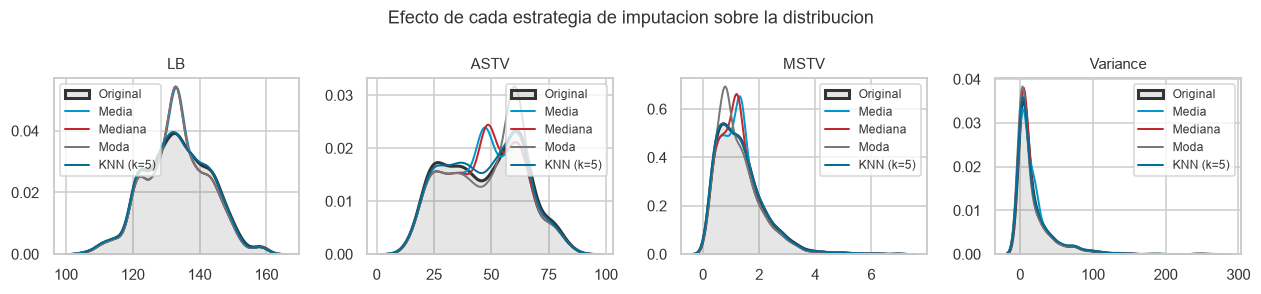

In [13]:
# Celda 3.4. Efecto visual de la imputacion sobre las distribuciones.
# Objetivo: mostrar graficamente la distorsion que introduce cada estrategia. La
#   comparacion se hace sobre cuatro variables de forma distinta: una simetrica,
#   una sesgada, una porcentual y una de conteo.
# Salidas: la figura fig_imputacion.

def comparar_distribuciones(df_real, dict_imputados, columnas, ncols=4):
    """Superpone la distribucion real y la imputada para cada variable.

    Parametros
    ----------
    df_real : DataFrame
        Datos completos originales, que hacen de verdad de referencia.
    dict_imputados : dict
        Diccionario {nombre_estrategia: DataFrame imputado}.
    columnas : list
        Variables a representar.
    ncols : int
        Numero de columnas de la rejilla de subgraficos.
    """
    nrows = int(np.ceil(len(columnas) / ncols))
    fig, ejes = plt.subplots(nrows, ncols, figsize=(ncols * 2.9, nrows * 2.7))
    ejes = np.atleast_1d(ejes).flatten()

    for eje, col in zip(ejes, columnas):
        # Distribucion verdadera como referencia, con area rellena.
        sns.kdeplot(df_real[col], ax=eje, color=UNIR_GRIS_OSC, lw=2,
                    label="Original", fill=True, alpha=0.12)
        # Una curva por estrategia de imputacion.
        for nombre, X_rec in dict_imputados.items():
            sns.kdeplot(X_rec[col], ax=eje, lw=1.3, label=nombre)
        eje.set_title(col, fontsize=10)
        eje.set_xlabel("")
        eje.set_ylabel("")
        eje.legend(fontsize=8)

    # Se eliminan los ejes sobrantes de la rejilla.
    for eje in ejes[len(columnas):]:
        fig.delaxes(eje)

    fig.suptitle("Efecto de cada estrategia de imputacion sobre la distribucion",
                 fontsize=12)
    plt.tight_layout()


comparar_distribuciones(X_completa, imputaciones,
                        ["LB", "ASTV", "MSTV", "Variance"])
guardar("fig_imputacion")

El experimento cuantifica lo que la teoría anticipaba. La imputación por vecinos
más cercanos gana en las tres métricas: su RMSE normalizado es de 0,224 frente a
0,382 de la media, 0,399 de la mediana y 0,481 de la moda, casi la mitad de
error. La razón es que estima cada hueco a partir de las cinco observaciones más
parecidas y aprovecha la correlación documentada en el apartado 2.4, estructura
que los imputadores por constante ignoran.

Todas comprimen la dispersión, con el ratio de desviaciones típicas por debajo de
1: sustituir el 10 % de los valores por un número central reduce la varianza de
forma mecánica. La media es la que más la degrada, con 0,949, y el método de
vecinos la que menos, con 0,983. Este último es además el único que preserva la
estructura de correlaciones, decisivo para el análisis de componentes principales
posterior: su error medio en la matriz es de 0,006, cuatro veces menor que el de
la media y seis veces menor que el de la moda.

La figura 4 muestra un aspecto que el RMSE no captura. La media, en cian claro, y
la mediana, en rojo, crean un pico artificial en el valor central de `ASTV` y de
`MSTV` que no existe en la distribución real. La moda, en gris, deforma el pico
de `LB` y de `MSTV` al concentrar masa en el valor más frecuente. La curva de
vecinos, en cian oscuro, se superpone casi exactamente al área sombreada de la
distribución original.

Si en este conjunto hubiera habido faltantes reales y dispersos, la elección
correcta habría sido la imputación por vecinos más cercanos, y por un margen
amplio. La media y la mediana quedan muy igualadas, porque la primera reconstruye
algo mejor y la segunda conserva algo mejor la dispersión, mientras que la moda
debe descartarse para variables continuas. Pero como los faltantes proceden de
tres filas que no son observaciones, se aplica la eliminación y el conjunto de
trabajo queda con 2 126 registros completos.

# 4. Preparación de la matriz de características

Decidir con qué columnas se alimenta a los algoritmos es la decisión de mayor
impacto del trabajo, y se toma con las evidencias del análisis exploratorio.

Se descartan `FileName`, `Date`, `SegFile`, `b` y `e` porque identifican el
registro y no describen al feto; `LBE` por duplicar exactamente a `LB`; `DR` por
ser constante e igual a cero, con varianza nula; `Width` por ser combinación
lineal exacta de otras dos columnas; y las diez indicadoras de `A` a `SUSP` por
ser la codificación disyuntiva de `CLASS`. Se apartan `CLASS` y `NSP` como verdad
de referencia externa. Las veinte columnas restantes son descriptores genuinos
del trazado y forman la matriz de trabajo.

## 4.1 Por qué importa eliminar la variable Width

La igualdad entre `Width` y la diferencia de `Max` y `Min` se cumple en las 2 126
filas sin excepción, lo que deja la matriz con rango 20 sobre 21 columnas: su
matriz de covarianzas es singular y no puede invertirse. La distancia de
Mahalanobis exige esa inversión, de modo que mantener `Width` haría fracasar uno
de los cinco detectores de la sección 5. Es un ejemplo de por qué el análisis
exploratorio debe preceder al modelado.

## 4.2 Por qué estandarizar

K-Means, DBSCAN, el factor local de atipicidad y la distancia de Mahalanobis se
basan en distancias. Con las escalas originales `Variance`, de 0 a 269, pesaría
cientos de veces más que `MSTV`, entre 0 y 7, solo por su unidad de medida. La
estandarización resta a cada valor la media de su columna y lo divide entre la
desviación típica, dejando todas las variables con media cero y desviación uno,
de manera que cada descriptor contribuye en igualdad de condiciones.

In [14]:
# Celda 4.1. Construccion de la matriz de caracteristicas.
# Objetivo: materializar las decisiones descritas arriba y verificar
#   numericamente que se resuelven los problemas detectados.
# Salidas: X, la matriz sin escalar; Z, la matriz estandarizada; y las etiquetas
#   y_nsp e y_class, apartadas para la validacion externa.

# Verificacion previa de las redundancias detectadas en el EDA.
print("Comprobaciones de redundancia:")
print("  LBE identica a LB          :", bool((df["LBE"] == df["LB"]).all()))
print("  DR constante               :", df["DR"].nunique() == 1,
      "(valores unicos:", df["DR"].unique().tolist(), ")")
print("  Width == Max - Min         :", bool((df["Width"] == (df["Max"] - df["Min"])).all()))

# Conjunto final de variables
VARIABLES_MODELO = ["LB", "AC", "FM", "UC", "ASTV", "MSTV", "ALTV", "MLTV",
                    "DL", "DS", "DP", "Min", "Max", "Nmax", "Nzeros",
                    "Mode", "Mean", "Median", "Variance", "Tendency"]

X = df[VARIABLES_MODELO].copy()          # matriz en unidades originales
y_nsp = df["NSP"].astype(int).values     # etiqueta apartada (3 niveles)
y_class = df["CLASS"].astype(int).values # etiqueta apartada (10 patrones)

print("\nMatriz de caracteristicas:", X.shape[0], "observaciones x",
      X.shape[1], "variables")

# Estandarizacion: StandardScaler calcula mu y sigma por columna y aplica
# z = (x - mu) / sigma.
escalador = StandardScaler()
Z = escalador.fit_transform(X)

print("\nEfecto de la estandarizacion (3 variables de control):")
print("  %-10s %12s %12s | %10s %10s" % ("Variable", "media orig.", "desv. orig.",
                                          "media z", "desv. z"))
for v in ["LB", "MSTV", "Variance"]:
    k = VARIABLES_MODELO.index(v)
    print("  %-10s %12.2f %12.2f | %10.2f %10.2f"
          % (v, X[v].mean(), X[v].std(), Z[:, k].mean(), Z[:, k].std()))

# La matriz debe tener rango completo para que su covarianza sea invertible.
rango = np.linalg.matrix_rank(Z)
print("\nRango de la matriz estandarizada:", rango, "de", Z.shape[1], "columnas")
assert rango == Z.shape[1], "La matriz sigue siendo singular: revisar redundancias"
print("Verificacion superada: la covarianza es invertible.")

RES["n_variables_modelo"] = len(VARIABLES_MODELO)
RES["variables_modelo"] = VARIABLES_MODELO

Comprobaciones de redundancia:
  LBE identica a LB          : True
  DR constante               : True (valores unicos: [0.0] )
  Width == Max - Min         : True

Matriz de caracteristicas: 2126 observaciones x 20 variables

Efecto de la estandarizacion (3 variables de control):
  Variable    media orig.  desv. orig. |    media z    desv. z
  LB               133.30         9.84 |       0.00       1.00
  MSTV               1.33         0.88 |       0.00       1.00
  Variance          18.81        28.98 |      -0.00       1.00

Rango de la matriz estandarizada: 20 de 20 columnas
Verificacion superada: la covarianza es invertible.


Varianza explicada por las primeras componentes principales:
  CP    individual    acumulada
   1        27.5 %       27.5 %
   2        15.8 %       43.3 %
   3         9.1 %       52.4 %
   4         7.3 %       59.8 %
   5         5.8 %       65.6 %
   6         5.2 %       70.8 %
  Componentes necesarias: 9 para el 80 % de la varianza y 12 para el 90 %


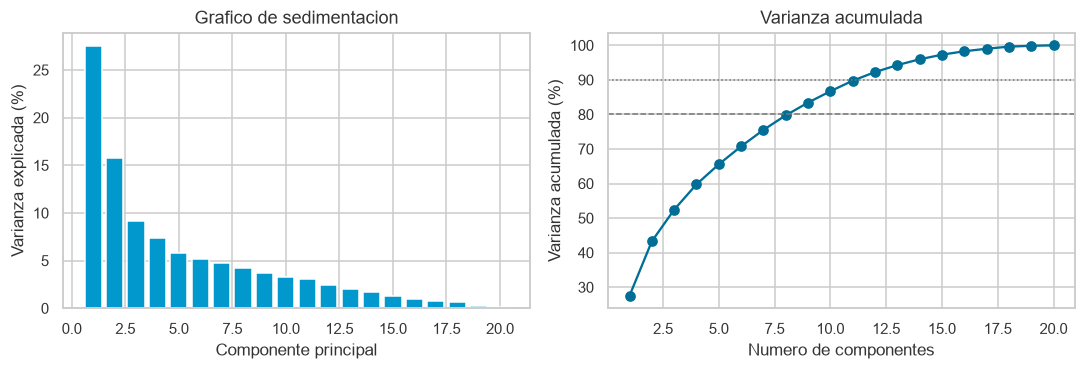


Cargas extremas de CP1: MSTV -0.31, Variance -0.28, DL -0.28, DP -0.23, Mode +0.32, Min +0.32, Median +0.33, Mean +0.36
Cargas extremas de CP2: ALTV -0.20, Min -0.20, ASTV -0.16, DS -0.07, Nmax +0.30, Mode +0.33, Median +0.33, Max +0.42


In [15]:
# Celda 4.2. Analisis de componentes principales.
# Objetivo: cuantificar la dimensionalidad efectiva del problema y obtener una
#   proyeccion en dos dimensiones que se reutilizara para visualizar tanto las
#   anomalias de la seccion 5 como los grupos de la seccion 6.
# Nota: el PCA se ajusta sobre datos ya estandarizados, lo que equivale a
#   diagonalizar la matriz de correlaciones y no la de covarianzas.
# Salidas: el objeto pca, la matriz Z_pca con todas las componentes y Z2 con las
#   dos primeras.

pca = PCA(random_state=SEMILLA)
Z_pca = pca.fit_transform(Z)

varianza = pca.explained_variance_ratio_
acumulada = np.cumsum(varianza)

print("Varianza explicada por las primeras componentes principales:")
print("  CP    individual    acumulada")
for i in range(6):
    print("  %2d    %8.1f %%   %8.1f %%" % (i + 1, 100 * varianza[i], 100 * acumulada[i]))

# Componentes necesarias para retener el 80 % y el 90 % de la varianza.
n80 = int(np.searchsorted(acumulada, 0.80) + 1)
n90 = int(np.searchsorted(acumulada, 0.90) + 1)
print("  Componentes necesarias: %d para el 80 %% de la varianza y %d para el 90 %%"
      % (n80, n90))

# Grafico de sedimentacion y varianza acumulada
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))

a1.bar(range(1, len(varianza) + 1), 100 * varianza, color=UNIR_CIAN)
a1.set_xlabel("Componente principal")
a1.set_ylabel("Varianza explicada (%)")
a1.set_title("Grafico de sedimentacion")

a2.plot(range(1, len(acumulada) + 1), 100 * acumulada, "o-", color=UNIR_CIAN_OSC)
a2.axhline(80, ls="--", color=UNIR_GRIS, lw=1)
a2.axhline(90, ls=":", color=UNIR_GRIS, lw=1)
a2.set_xlabel("Numero de componentes")
a2.set_ylabel("Varianza acumulada (%)")
a2.set_title("Varianza acumulada")
plt.tight_layout()
guardar("fig_pca_varianza")

# Las cargas indican con que peso entra cada variable original en cada
# componente, y son la clave para interpretarlas.
cargas = pd.DataFrame(pca.components_[:2].T, index=VARIABLES_MODELO,
                      columns=["CP1", "CP2"]).round(3)
def resumen_cargas(cp, n=4):
    """Devuelve, en una sola linea, las n cargas mas negativas y las n mas positivas."""
    orden = cargas[cp].sort_values()
    extremos = list(orden.head(n).items()) + list(orden.tail(n).items())
    return ", ".join("%s %+.2f" % (v, x) for v, x in extremos)


print("\nCargas extremas de CP1:", resumen_cargas("CP1"))
print("Cargas extremas de CP2:", resumen_cargas("CP2"))

Z2 = Z_pca[:, :2]            # proyeccion 2D reutilizada en todas las figuras
Z_pca80 = Z_pca[:, :n80]     # espacio reducido al 80 % de varianza

RES["pca_var"] = [round(float(v), 4) for v in varianza[:8]]
RES["pca_n80"] = n80

La primera componente explica el 27,5 % de la varianza y la segunda el 15,8 %,
de modo que entre ambas apenas superan el 43 % y hacen falta nueve para alcanzar
el 80 %. El problema no es de dimensionalidad trivial: no puede resumirse en dos
ejes sin perder información sustancial, así que las dos primeras componentes se
usarán solo para visualizar.

Las cargas admiten lectura clínica directa. La primera componente contrapone las
variables de tendencia central y anchura del histograma, `Mean`, `Mode`, `Median`
y `Max`, frente a las de variabilidad anormal, `ASTV` y `ALTV`. La segunda separa
la actividad del registro, medida por `AC`, `FM` y `UC`, de las deceleraciones.
Son los dos ejes con los que un obstetra describiría un trazado.

# 5. Detección de anomalías

## 5.1 Planteamiento

Una anomalía es una observación que se aparta del comportamiento mayoritario del
conjunto. La pregunta operativa aquí es si se pueden señalar automáticamente los
trazados inusuales sin recurrir al diagnóstico del obstetra.

Se aplican cinco técnicas de tres familias. El Z-score y la regla de Tukey son
univariantes: el primero marca una observación cuando algún valor tipificado
supera 3 en valor absoluto, y asume normalidad; la segunda la marca cuando algún
valor cae fuera del intervalo entre el primer cuartil menos vez y media el rango
intercuartílico y el tercer cuartil más esa cantidad, sin asumir distribución
alguna pero examinando las variables de una en una. La distancia de Mahalanobis
con estimación robusta de la covarianza es multivariante, mide la separación al
centro ponderándola por la correlación y presupone normalidad multivariante.
Isolation Forest es un ensamble de árboles apoyado en que los puntos raros se
aíslan con pocos cortes aleatorios. Y el factor local de atipicidad, LOF, compara
la densidad de cada punto con la de sus vecinos; ninguno de los dos últimos
impone supuestos distribucionales.

Para que la comparación sea justa, los métodos multivariantes se calibran al
mismo 5 % de observaciones marcadas. La evaluación no se limita a contar: se
recurre a `NSP`, que ningún modelo ha visto, para medir el enriquecimiento en
casos patológicos, magnitud conocida como lift y definida como el cociente entre
la probabilidad de que una observación sea patológica dado que el detector la ha
marcado y la probabilidad de que lo sea sin más información. Un lift de 1
significa que el detector no aporta nada frente al azar.

## 5.2 Métodos univariantes de referencia

In [16]:
# Celda 5.1. Metodos univariantes: Z-score y regla de Tukey.
# Objetivo: establecer una linea base con las dos reglas clasicas. Se aplican
#   variable a variable y se marca la fila cuando alguna de sus 20 variables
#   resulta atipica.
# Salidas: las mascaras booleanas anom_zscore y anom_iqr.

# Z-score: se marca cuando |x - mu| / sigma supera 3. Bajo normalidad, ese
# umbral deja fuera solo el 0,27 % de los casos por variable.
puntuaciones_z = np.abs((X - X.mean()) / X.std())
anom_zscore = (puntuaciones_z > 3).any(axis=1).values

# Regla de Tukey: fuera de [Q1 - 1.5*RIC, Q3 + 1.5*RIC].
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
RIC = Q3 - Q1
limite_inf = Q1 - 1.5 * RIC
limite_sup = Q3 + 1.5 * RIC
anom_iqr = ((X < limite_inf) | (X > limite_sup)).any(axis=1).values

print("METODOS UNIVARIANTES DE REFERENCIA\n")
print("Z-score (|z| > 3)      : %4d filas marcadas (%.1f %% del conjunto)"
      % (anom_zscore.sum(), 100 * anom_zscore.mean()))
print("Tukey (1.5 x RIC)      : %4d filas marcadas (%.1f %% del conjunto)"
      % (anom_iqr.sum(), 100 * anom_iqr.mean()))

# El problema de fondo es que la probabilidad de falso positivo se acumula con
# el numero de variables analizadas simultaneamente.
p_falso_positivo = 1 - (1 - 0.0027) ** len(VARIABLES_MODELO)
print("\nProbabilidad teorica de que una fila NORMAL sea marcada por el Z-score")
print("al examinar %d variables independientes: %.1f %%"
      % (len(VARIABLES_MODELO), 100 * p_falso_positivo))

RES["n_zscore"] = int(anom_zscore.sum())
RES["n_iqr"] = int(anom_iqr.sum())

METODOS UNIVARIANTES DE REFERENCIA

Z-score (|z| > 3)      :  343 filas marcadas (16.1 % del conjunto)
Tukey (1.5 x RIC)      : 1220 filas marcadas (57.4 % del conjunto)

Probabilidad teorica de que una fila NORMAL sea marcada por el Z-score
al examinar 20 variables independientes: 5.3 %


Las reglas univariantes fracasan. El Z-score marca 343 filas, el 16,1 % del
total, más de tres veces la contaminación razonable. La regla de Tukey marca
1 220 filas, el 57,4 %: un detector que declara anómala a más de la mitad de la
población no detecta nada.

La causa es doble. Por un lado, las comparaciones múltiples: aun suponiendo
normalidad e independencia, examinar 20 variables con umbral de 3 desviaciones
típicas eleva la probabilidad acumulada de falso positivo al 5,3 % por fila. Por
otro, y más importante, las variables no son normales, y con asimetrías extremas
y exceso de ceros el rango intercuartílico se vuelve minúsculo, de modo que casi
cualquier valor no nulo cae fuera de los bigotes.

La anormalidad de un trazado no reside en ninguna variable aislada sino en la
combinación de sus valores, y capturarla exige métodos multivariantes.

## 5.3 Distancia de Mahalanobis robusta

Umbral teorico chi2(0.975, 20 gl) = 34.2
  marcaria 646 filas (30.4 % del conjunto)

Umbral empirico al 5 % (d^2 >= 465.5)
  marca 106 filas (5.0 % del conjunto)


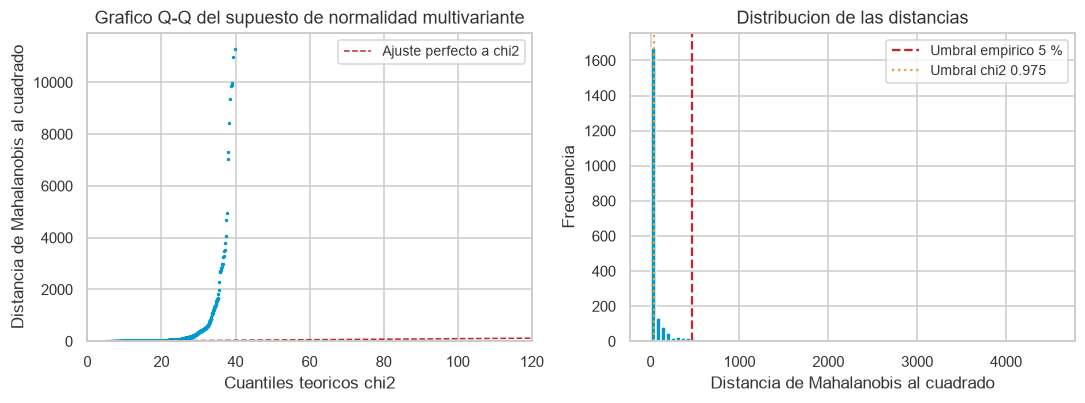

In [17]:
# Celda 5.2. Distancia de Mahalanobis con estimacion robusta de la covarianza.
# Objetivo: primer metodo multivariante. La distancia de Mahalanobis mide la
#   separacion al centro de la nube teniendo en cuenta la correlacion, mediante
#   d^2(x) = (x - mu)^T S^-1 (x - mu). Se usa el estimador MCD, que busca el
#   subconjunto mas compacto de los datos, en lugar de la media y la covarianza
#   muestrales, porque estas son ellas mismas sensibles a los atipicos y
#   producen el llamado efecto de enmascaramiento.
# Salidas: dist_mahalanobis y la mascara anom_mahalanobis.

# support_fraction = 0.85 indica que el MCD busca el subconjunto del 85 % de los
# datos cuya covarianza tiene el menor determinante, es decir, el nucleo denso.
mcd = MinCovDet(support_fraction=0.85, random_state=SEMILLA).fit(Z)
dist_mahalanobis = mcd.mahalanobis(Z)     # devuelve d^2, no d

# Criterio A: umbral teorico chi-cuadrado. Bajo normalidad multivariante, d^2
# sigue una distribucion chi2 con p grados de libertad.
umbral_chi2 = stats.chi2.ppf(0.975, df=len(VARIABLES_MODELO))
marcados_chi2 = dist_mahalanobis > umbral_chi2

# Criterio B: proporcion fija del 5 %, para poder comparar con los demas.
N_ANOMALIAS = int(round(0.05 * len(Z)))
umbral_5pct = np.sort(dist_mahalanobis)[-N_ANOMALIAS]
anom_mahalanobis = dist_mahalanobis >= umbral_5pct

print("Umbral teorico chi2(0.975, %d gl) = %.1f" % (len(VARIABLES_MODELO), umbral_chi2))
print("  marcaria %d filas (%.1f %% del conjunto)"
      % (marcados_chi2.sum(), 100 * marcados_chi2.mean()))
print("\nUmbral empirico al 5 %% (d^2 >= %.1f)" % umbral_5pct)
print("  marca %d filas (%.1f %% del conjunto)"
      % (anom_mahalanobis.sum(), 100 * anom_mahalanobis.mean()))

# Contraste del supuesto de normalidad multivariante. Si se cumpliera, los
# cuantiles empiricos de d^2 coincidirian con los de la chi2.
cuantiles_teoricos = stats.chi2.ppf(
    (np.arange(len(Z)) + 0.5) / len(Z), df=len(VARIABLES_MODELO))

plt.figure(figsize=(10, 3.8))
plt.subplot(1, 2, 1)
plt.plot(cuantiles_teoricos, np.sort(dist_mahalanobis), ".", ms=2.5, color=UNIR_CIAN)
lim = max(cuantiles_teoricos.max(), 120)
plt.plot([0, lim], [0, lim], "--", color=UNIR_ROJO, lw=1, label="Ajuste perfecto a chi2")
plt.xlim(0, lim); plt.ylim(0, np.percentile(dist_mahalanobis, 99.5))
plt.xlabel("Cuantiles teoricos chi2"); plt.ylabel("Distancia de Mahalanobis al cuadrado")
plt.title("Grafico Q-Q del supuesto de normalidad multivariante")
plt.legend(fontsize=9)

plt.subplot(1, 2, 2)
plt.hist(dist_mahalanobis, bins=80, color=UNIR_CIAN, range=(0, np.percentile(dist_mahalanobis, 99)))
plt.axvline(umbral_5pct, color=UNIR_ROJO, ls="--", label="Umbral empirico 5 %")
plt.axvline(umbral_chi2, color=UNIR_AMBAR, ls=":", label="Umbral chi2 0.975")
plt.xlabel("Distancia de Mahalanobis al cuadrado"); plt.ylabel("Frecuencia")
plt.title("Distribucion de las distancias")
plt.legend(fontsize=9)
plt.tight_layout()
guardar("fig_mahalanobis")

RES["n_mahalanobis_chi2"] = int(marcados_chi2.sum())

El gráfico cuantil-cuantil se separa pronto de la diagonal: las distancias
observadas crecen mucho más rápido que las que predice la chi-cuadrado. El
supuesto de normalidad multivariante no se cumple, y por eso el umbral teórico
marca 646 observaciones, el 30,4 % del conjunto, cifra sin sentido operativo
porque ningún servicio revisaría a mano tres de cada diez registros. Se conserva
el umbral empírico del 5 %, que además permite comparar el método con Isolation
Forest y con LOF en igualdad de condiciones.

## 5.4 Isolation Forest

Propuesto por Liu, Ting y Zhou (2008), parte de una observación sencilla: si se
particiona el espacio eligiendo al azar una variable y un punto de corte, un
punto anómalo queda aislado en muy pocos cortes mientras que uno del núcleo denso
necesita muchos. El algoritmo construye un bosque de árboles aleatorios y asigna
a cada observación una puntuación según su profundidad media de aislamiento.

A diferencia de casi todos los demás, no modela la normalidad para buscar
desviaciones sino que modela directamente la rareza. No asume distribución
alguna, tolera la alta dimensionalidad y su coste es lineal.

In [18]:
# Celda 5.3. Isolation Forest.
# Objetivo: detectar anomalias mediante aislamiento aleatorio recursivo.
# Parametros: n_estimators = 200 fija el numero de arboles, y cuantos mas haya
#   mas estable es la puntuacion; contamination = 0.05 declara la proporcion
#   esperada de anomalias y con ello fija el umbral de decision; max_samples =
#   256 es la submuestra por arbol recomendada por los autores, ya que
#   submuestrear mejora la deteccion al reducir el enmascaramiento entre
#   anomalias proximas.
# Salidas: score_iforest, donde un valor mayor indica mas anomalo, y la mascara
#   anom_iforest.

iforest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples=256,
    random_state=SEMILLA,
    n_jobs=-1,
)
# fit_predict devuelve -1 para las anomalias y +1 para las observaciones normales.
etiquetas_if = iforest.fit_predict(Z)
anom_iforest = etiquetas_if == -1

# score_samples devuelve valores negativos y cuanto menor es el valor, mas
# anomala es la observacion. Se invierte el signo para que "mayor" signifique
# "mas anomalo" y la lectura resulte natural.
score_iforest = -iforest.score_samples(Z)

print("Isolation Forest: %d arboles, %d observaciones marcadas (%.1f %%), "
      "umbral aprendido %.4f"
      % (iforest.n_estimators, anom_iforest.sum(),
         100 * anom_iforest.mean(), -iforest.offset_))
print("Puntuacion de anormalidad: min %.3f | mediana %.3f | max %.3f"
      % (score_iforest.min(), np.median(score_iforest), score_iforest.max()))

# Para saber QUE hace anomalas a las observaciones marcadas se compara su perfil
# medio, en unidades z, con el del resto del conjunto.
perfil = pd.DataFrame({
    "Media z (anomalias)": Z[anom_iforest].mean(axis=0),
    "Media z (resto)": Z[~anom_iforest].mean(axis=0),
}, index=VARIABLES_MODELO)
perfil["Diferencia"] = (perfil["Media z (anomalias)"] - perfil["Media z (resto)"]).round(2)
perfil = perfil.round(2).reindex(perfil["Diferencia"].abs().sort_values(ascending=False).index)

print("\nPerfil de las anomalias detectadas (en desviaciones tipicas):\n")
print(perfil.head(8).to_string())

RES["perfil_iforest"] = perfil.head(8)["Diferencia"].to_dict()

Isolation Forest: 200 arboles, 107 observaciones marcadas (5.0 %), umbral aprendido 0.5242
Puntuacion de anormalidad: min 0.365 | mediana 0.420 | max 0.627

Perfil de las anomalias detectadas (en desviaciones tipicas):

          Media z (anomalias)  Media z (resto)  Diferencia
Variance                 2.22            -0.12        2.33
DP                       2.10            -0.11        2.22
MSTV                     1.60            -0.08        1.68
Max                      1.47            -0.08        1.54
Mean                    -1.41             0.07       -1.48
Mode                    -1.32             0.07       -1.39
Nmax                     1.26            -0.07        1.33
DL                       1.25            -0.07        1.32


El perfil de las observaciones marcadas es clínicamente coherente y sirve de
validación cualitativa. Las ocho variables que más las separan del resto las
sitúan muy por encima de la media en `Variance`, con 2,33 desviaciones típicas de
diferencia, en `DP`, las deceleraciones prolongadas, con 2,22, en `MSTV`,
variabilidad errática a corto plazo, con 1,68, y también en `Max`, `Nmax` y `DL`;
y muy por debajo en `Mean`, con 1,48 menos, y en `Mode`, con 1,39, con el mismo
desplazamiento atenuado en `Median` y `Min`.

En lenguaje clínico, el algoritmo ha aislado trazados con bradicardia, ya que
toda la tendencia central aparece desplazada a la baja, acompañada de
deceleraciones prolongadas y severas y de variabilidad amplia y errática. Es la
descripción de manual de un trazado no tranquilizador, reconstruida sin haber
visto un solo diagnóstico.

Un matiz: `ALTV` aparece por debajo de la media en las anomalías, con 0,54
desviaciones típicas menos. Isolation Forest no captura el fenotipo del trazado
plano, de variabilidad reducida y monótona, sino el errático y decelerativo. Son
dos formas distintas de compromiso fetal y el detector se especializa en la
segunda.

## 5.5 Factor local de atipicidad

Propuesto por Breunig y sus colaboradores en 2000, no busca puntos lejanos del
centro sino situados en zonas menos densas que su propio vecindario: compara la
densidad local de cada observación con la media de sus k vecinos, y un cociente
muy superior a 1 indica que el punto está más solo que quienes lo rodean.

Su ventaja es detectar anomalías locales, anómalas respecto de su grupo aunque no
sean extremas en el conjunto global. Su debilidad, la dependencia crítica de k y
la degradación de la densidad en dimensión alta.

In [19]:
# Celda 5.4. Factor local de atipicidad (LOF).
# Objetivo: detectar anomalias por contraste de densidad local.
# Parametros: n_neighbors = 20 fija el tamano del vecindario, valor por defecto
#   recomendado, ya que un vecindario demasiado pequeno introduce ruido y uno
#   demasiado grande borra el caracter local del metodo; contamination = 0.05
#   mantiene la misma proporcion que Isolation Forest para poder comparar.
# Salidas: score_lof y la mascara anom_lof.

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
etiquetas_lof = lof.fit_predict(Z)
anom_lof = etiquetas_lof == -1

# negative_outlier_factor_ es el LOF con el signo cambiado; se reinvierte.
score_lof = -lof.negative_outlier_factor_

print("Local Outlier Factor")
print("  Tamano del vecindario  :", lof.n_neighbors)
print("  Observaciones marcadas : %d (%.1f %%)" % (anom_lof.sum(), 100 * anom_lof.mean()))
print("  Factor LOF: min = %.2f | mediana = %.2f | max = %.2f"
      % (score_lof.min(), np.median(score_lof), score_lof.max()))

# Sensibilidad al parametro k: se comprueba cuanto cambia el conjunto detectado
# al variar el tamano del vecindario.
print("\nSensibilidad al numero de vecinos (solapamiento con k = 20):")
base_lof = anom_lof
for k in [5, 10, 20, 35, 50]:
    m = LocalOutlierFactor(n_neighbors=k, contamination=0.05).fit_predict(Z) == -1
    jac = (m & base_lof).sum() / (m | base_lof).sum()
    print("  k = %2d: %3d marcadas, indice de Jaccard con k=20: %.3f" % (k, m.sum(), jac))

Local Outlier Factor
  Tamano del vecindario  : 20
  Observaciones marcadas : 107 (5.0 %)
  Factor LOF: min = 0.95 | mediana = 1.07 | max = 4.50

Sensibilidad al numero de vecinos (solapamiento con k = 20):
  k =  5: 107 marcadas, indice de Jaccard con k=20: 0.216
  k = 10: 107 marcadas, indice de Jaccard con k=20: 0.446
  k = 20: 107 marcadas, indice de Jaccard con k=20: 1.000
  k = 35: 107 marcadas, indice de Jaccard con k=20: 0.529
  k = 50: 107 marcadas, indice de Jaccard con k=20: 0.427


## 5.6 Comparación de los cinco detectores

Los cinco métodos ya han emitido su veredicto. La pregunta pendiente es cuál de
ellos resulta realmente útil, y para responderla se recupera la etiqueta `NSP`
que se había apartado al comienzo.

In [20]:
# Celda 5.5. Evaluacion comparativa contra la verdad de referencia externa.
# Objetivo: medir la utilidad real de cada detector usando NSP, que ningun
#   modelo ha visto. Se calcula el porcentaje de patologicos entre los marcados,
#   que actua como precision del detector; el lift, que es ese porcentaje
#   dividido por la tasa base; y el recall, que es la fraccion del total de
#   casos patologicos que el detector logra recuperar.
# Salidas: el DataFrame tabla_anomalias.

DETECTORES = {
    "Z-score (|z|>3)":      anom_zscore,
    "Tukey (1.5 RIC)":      anom_iqr,
    "Mahalanobis MCD (5 %)": anom_mahalanobis,
    "Isolation Forest (5 %)": anom_iforest,
    "LOF k=20 (5 %)":       anom_lof,
}

tasa_base = float((y_nsp == 3).mean())   # prevalencia de patologicos: 8,3 %
total_patologicos = int((y_nsp == 3).sum())

filas = []
for nombre, mascara in DETECTORES.items():
    n = int(mascara.sum())
    prec = float((y_nsp[mascara] == 3).mean())          # precision sobre NSP=3
    prec_23 = float((y_nsp[mascara] >= 2).mean())       # precision sobre no normales
    rec = float((y_nsp[mascara] == 3).sum() / total_patologicos)
    filas.append({
        "Metodo": nombre,
        "Marcadas": n,
        "% del conjunto": round(100 * n / len(Z), 1),
        "% patologicos": round(100 * prec, 1),
        "Lift": round(prec / tasa_base, 2),
        "% no normales": round(100 * prec_23, 1),
        "Recall NSP=3": round(100 * rec, 1),
    })

tabla_anomalias = pd.DataFrame(filas).set_index("Metodo")

print("EVALUACION DE LOS DETECTORES CONTRA LA ETIQUETA NSP\n")
print("Tasa base de casos patologicos: %.1f %%  (%d de %d)\n"
      % (100 * tasa_base, total_patologicos, len(y_nsp)))
print(tabla_anomalias.to_string())
print("\nUn lift de 1.00 significa que el detector no aporta nada sobre el azar.")

RES["tabla_anomalias"] = tabla_anomalias.reset_index().to_dict("records")
RES["tasa_base_nsp3"] = round(tasa_base, 4)

EVALUACION DE LOS DETECTORES CONTRA LA ETIQUETA NSP

Tasa base de casos patologicos: 8.3 %  (176 de 2126)

                        Marcadas  % del conjunto  % patologicos  Lift  % no normales  Recall NSP=3
Metodo                                                                                            
Z-score (|z|>3)              343            16.1           40.5  4.90           49.0          79.0
Tukey (1.5 RIC)             1220            57.4           13.7  1.65           30.4          94.9
Mahalanobis MCD (5 %)        106             5.0           41.5  5.01           49.1          25.0
Isolation Forest (5 %)       107             5.0           54.2  6.55           60.7          33.0
LOF k=20 (5 %)               107             5.0           17.8  2.14           39.3          10.8

Un lift de 1.00 significa que el detector no aporta nada sobre el azar.


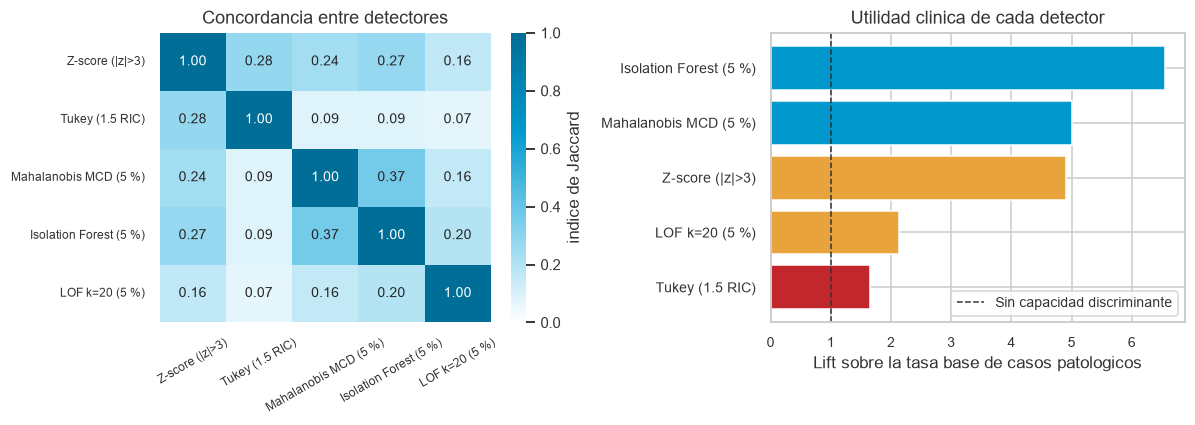

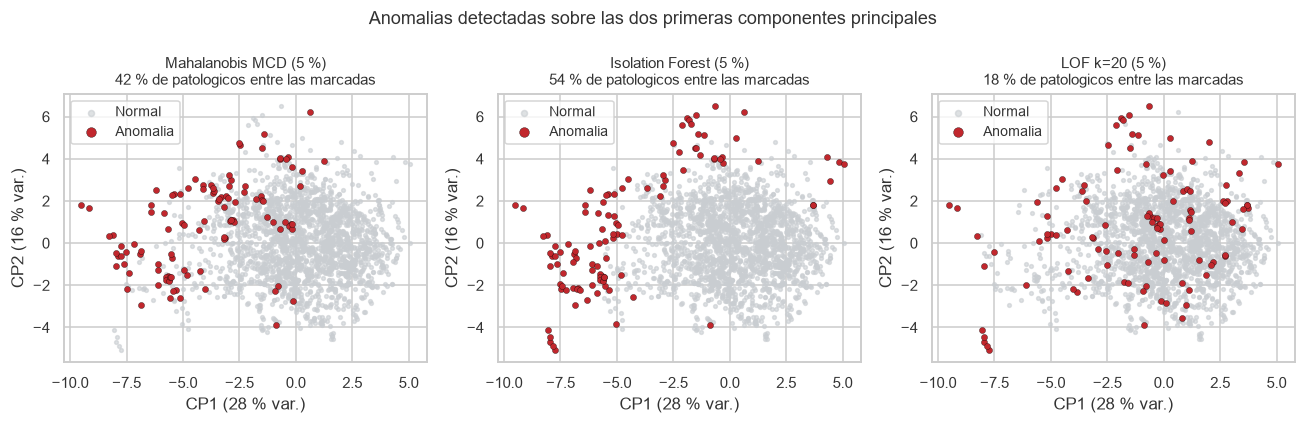

Indice de Jaccard entre los tres metodos multivariantes:
  Isolation Forest y Mahalanobis: 0.365
  Isolation Forest y LOF        : 0.196
  Mahalanobis y LOF             : 0.158


In [21]:
# Celda 5.6. Concordancia entre detectores y visualizacion.
# Objetivo: medir cuanto coinciden los metodos entre si mediante el indice de
#   Jaccard, definido como el tamano de la interseccion dividido por el de la
#   union; visualizar las anomalias sobre la proyeccion PCA; y comparar el lift
#   de forma grafica.
# Salidas: las figuras fig_anomalias_jaccard y fig_anomalias_pca.

nombres = list(DETECTORES.keys())
jaccard = np.ones((len(nombres), len(nombres)))
for i, ni in enumerate(nombres):
    for j, nj in enumerate(nombres):
        a, b = DETECTORES[ni], DETECTORES[nj]
        jaccard[i, j] = (a & b).sum() / max((a | b).sum(), 1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))

sns.heatmap(pd.DataFrame(jaccard, index=nombres, columns=nombres), annot=True,
            fmt=".2f", cmap=CMAP_SEQ, vmin=0, vmax=1, ax=a1,
            cbar_kws={"label": "indice de Jaccard"}, annot_kws={"size": 9})
a1.set_title("Concordancia entre detectores")
a1.tick_params(axis="x", rotation=30, labelsize=8)
a1.tick_params(axis="y", labelsize=8)

orden = tabla_anomalias["Lift"].sort_values()
colores = [UNIR_ROJO if v < 2 else UNIR_AMBAR if v < 5 else UNIR_CIAN for v in orden]
a2.barh(orden.index, orden.values, color=colores)
a2.axvline(1, color=UNIR_GRIS_OSC, ls="--", lw=1, label="Sin capacidad discriminante")
a2.set_xlabel("Lift sobre la tasa base de casos patologicos")
a2.set_title("Utilidad clinica de cada detector")
a2.tick_params(labelsize=9)
a2.legend(fontsize=9)
plt.tight_layout()
guardar("fig_anomalias_jaccard")

# Proyeccion PCA de las anomalias de los tres metodos multivariantes.
fig, ejes = plt.subplots(1, 3, figsize=(12, 3.9))
for eje, nombre in zip(ejes, ["Mahalanobis MCD (5 %)", "Isolation Forest (5 %)", "LOF k=20 (5 %)"]):
    m = DETECTORES[nombre]
    eje.scatter(Z2[~m, 0], Z2[~m, 1], s=6, c="#C9CDD1", label="Normal", alpha=0.6)
    eje.scatter(Z2[m, 0], Z2[m, 1], s=16, c=UNIR_ROJO, label="Anomalia", edgecolor="k", lw=0.2)
    eje.set_title("%s\n%.0f %% de patologicos entre las marcadas"
                  % (nombre, tabla_anomalias.loc[nombre, "% patologicos"]), fontsize=10)
    eje.set_xlabel("CP1 (%.0f %% var.)" % (100 * pca.explained_variance_ratio_[0]))
    eje.set_ylabel("CP2 (%.0f %% var.)" % (100 * pca.explained_variance_ratio_[1]))
    eje.legend(fontsize=9, markerscale=1.6)
fig.suptitle("Anomalias detectadas sobre las dos primeras componentes principales", fontsize=12)
plt.tight_layout()
guardar("fig_anomalias_pca")

print("Indice de Jaccard entre los tres metodos multivariantes:")
print("  Isolation Forest y Mahalanobis: %.3f" % jaccard[nombres.index("Isolation Forest (5 %)"),
                                                         nombres.index("Mahalanobis MCD (5 %)")])
print("  Isolation Forest y LOF        : %.3f" % jaccard[nombres.index("Isolation Forest (5 %)"),
                                                         nombres.index("LOF k=20 (5 %)")])
print("  Mahalanobis y LOF             : %.3f" % jaccard[nombres.index("Mahalanobis MCD (5 %)"),
                                                         nombres.index("LOF k=20 (5 %)")])
RES["jaccard_if_lof"] = float(round(jaccard[nombres.index("Isolation Forest (5 %)"),
                                            nombres.index("LOF k=20 (5 %)")], 3))

La evaluación externa ordena los cinco detectores de forma inequívoca. Isolation
Forest es el mejor con diferencia: de las 107 observaciones que marca, el 54,2 %
son patológicas frente a una tasa base del 8,3 %, un lift de 6,55. Recupera el
33 % de todos los casos patológicos examinando solo el 5 % de los registros, de
modo que una revisión manual de ese 5 % encontraría uno de cada dos casos graves.

La distancia de Mahalanobis robusta queda segunda con un lift de 5,01, resultado
notable dado que su supuesto de normalidad está violado; el estimador robusto
compensa buena parte del problema. El Z-score alcanza 4,90 pero a un coste
inaceptable, marcando el 16 % del conjunto, y su recall del 79 % es engañoso
porque se logra señalando una de cada seis observaciones.

El factor local de atipicidad es el peor de los multivariantes, con 2,14, por un
motivo estructural: busca anomalías locales y en veinte dimensiones la densidad
local se diluye, y además los trazados patológicos no forman puntos aislados sino
una región periférica poblada que LOF interpreta como vecindario legítimo. La
regla de Tukey no sirve en absoluto: lift de 1,65 marcando el 57 % del conjunto.

Un hallazgo transversal: los índices de Jaccard son bajos en toda la matriz, y en
particular Isolation Forest y LOF comparten apenas el 20 % de sus detecciones.
Ser una anomalía no es una propiedad absoluta del dato sino relativa al método, y
por eso elegir detector exige un criterio externo de utilidad como el que aporta
`NSP`.

Se adopta Isolation Forest al 5 % como detector de referencia. Sus 107 anomalías
no se eliminan, porque en un problema clínico los atípicos son la señal de interés
y no ruido; se conservan marcadas y en la sección siguiente se comprueba que el
agrupamiento las ubica en un grupo propio.

# 6. Técnicas de agrupamiento

## 6.1 Planteamiento

El agrupamiento particiona las observaciones en grupos internamente homogéneos y
mutuamente diferenciados sin recurrir a ninguna etiqueta. Se aplican tres
algoritmos de familias distintas.

K-Means es particional, minimiza la inercia dentro de cada grupo, tiende a grupos
esféricos de tamaño parecido y exige fijar su número. DBSCAN se basa en densidad:
busca regiones densas separadas por regiones vacías, admite formas arbitrarias,
no obliga a fijar el número y etiqueta como ruido lo que no encaja. El jerárquico
aglomerativo con criterio de Ward construye fusiones sucesivas que minimizan el
incremento de varianza, produce grupos compactos y anidados y permite decidir el
número a posteriori, cortando el árbol.

Se emplean dos tipos de métricas. Las internas se calculan solo con los datos: el
coeficiente de silueta, entre menos uno y uno, que mide cohesión frente a
separación; el índice de Davies-Bouldin, que compara dispersión y separación y
conviene bajo; y el de Calinski-Harabasz, que relaciona la varianza entre grupos
con la interna y conviene alto. Las externas contrastan la partición con `NSP`,
que no interviene en el ajuste: el índice de Rand ajustado y la información mutua
normalizada, donde un cero equivale a una partición aleatoria.

## 6.2 K-Means: elección del número de grupos

In [22]:
# Celda 6.1. Barrido del numero de grupos k para K-Means.
# Objetivo: evaluar k entre 2 y 10 con cuatro criterios de validacion interna y
#   dos de validacion externa, para decidir el numero de grupos con evidencia y
#   no por intuicion.
# Nota: n_init = 20 relanza el algoritmo veinte veces con inicializaciones
#   distintas y conserva la mejor, lo que mitiga su dependencia del arranque
#   aleatorio, ya que K-Means solo garantiza alcanzar un optimo local.
# Salidas: el DataFrame barrido_k.

RANGO_K = range(2, 11)
registros = []

for k in RANGO_K:
    modelo = KMeans(n_clusters=k, n_init=20, random_state=SEMILLA).fit(Z)
    etiquetas = modelo.labels_
    registros.append({
        "k": k,
        "Inercia": round(modelo.inertia_, 1),
        "Silueta": round(silhouette_score(Z, etiquetas), 4),
        "Davies-Bouldin": round(davies_bouldin_score(Z, etiquetas), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(Z, etiquetas), 1),
        "ARI vs NSP": round(adjusted_rand_score(y_nsp, etiquetas), 4),
        "NMI vs NSP": round(normalized_mutual_info_score(y_nsp, etiquetas), 4),
    })

barrido_k = pd.DataFrame(registros).set_index("k")
print("Barrido del numero de grupos (validacion interna y externa):")
print(barrido_k.to_string())

# Deteccion analitica del codo de la curva de inercia. Se define como el punto
# de maxima distancia perpendicular a la recta que une el primer y el ultimo
# valor de la curva, lo que evita la lectura subjetiva del grafico.
ks = np.array(list(RANGO_K), dtype=float)
inercias = barrido_k["Inercia"].values.astype(float)
p1 = np.array([ks[0], inercias[0]])
p2 = np.array([ks[-1], inercias[-1]])
direccion = (p2 - p1) / np.linalg.norm(p2 - p1)
distancias = []
for x, yv in zip(ks, inercias):
    v = np.array([x, yv]) - p1
    distancias.append(np.linalg.norm(v - np.dot(v, direccion) * direccion))
k_codo = int(ks[int(np.argmax(distancias))])
print("\nCodo detectado analiticamente en k =", k_codo)

RES["barrido_k"] = barrido_k.reset_index().to_dict("records")
RES["k_codo"] = k_codo

Barrido del numero de grupos (validacion interna y externa):
    Inercia  Silueta  Davies-Bouldin  Calinski-Harabasz  ARI vs NSP  NMI vs NSP
k                                                                              
2   35166.1   0.1832          2.0107              444.2      0.0160      0.0864
3   31323.9   0.1572          1.9233              379.4      0.2142      0.2224
4   28241.2   0.1543          1.8186              357.6      0.0908      0.1822
5   26076.2   0.1610          1.5396              334.4      0.0883      0.1780
6   24366.9   0.1522          1.6241              315.9      0.1224      0.2257
7   22783.4   0.1568          1.4705              305.9      0.1261      0.2236
8   21572.2   0.1479          1.5920              293.8      0.1012      0.2172
9   20469.0   0.1558          1.5537              285.1      0.0788      0.2030
10  19671.6   0.1603          1.5635              273.1      0.0681      0.2003

Codo detectado analiticamente en k = 5


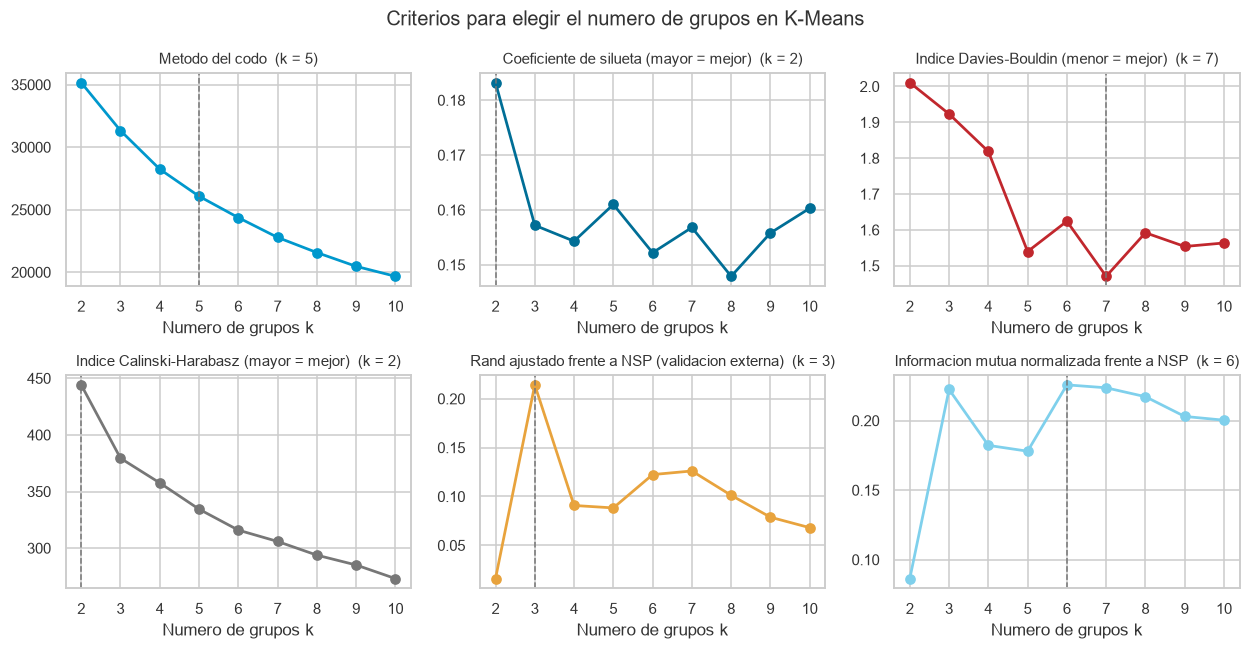

In [23]:
# Celda 6.2. Representacion grafica de los criterios de seleccion de k.
# Objetivo: mostrar en un solo panel los cuatro criterios internos y los dos
#   externos, para que el conflicto entre ellos resulte visible de un vistazo.
# Salidas: la figura fig_kmeans_seleccion.

fig, ejes = plt.subplots(2, 3, figsize=(11.5, 6.0))

paneles = [
    ("Inercia", "Metodo del codo", UNIR_CIAN, None),
    ("Silueta", "Coeficiente de silueta (mayor = mejor)", UNIR_CIAN_OSC, "max"),
    ("Davies-Bouldin", "Indice Davies-Bouldin (menor = mejor)", UNIR_ROJO, "min"),
    ("Calinski-Harabasz", "Indice Calinski-Harabasz (mayor = mejor)", UNIR_GRIS, "max"),
    ("ARI vs NSP", "Rand ajustado frente a NSP (validacion externa)", UNIR_AMBAR, "max"),
    ("NMI vs NSP", "Informacion mutua normalizada frente a NSP", UNIR_CIAN_CLA, "max"),
]

for eje, (columna, titulo, color, optimo) in zip(ejes.flatten(), paneles):
    serie = barrido_k[columna]
    eje.plot(serie.index, serie.values, "o-", color=color, lw=1.8)
    # Se marca el k optimo segun ese criterio concreto.
    if optimo == "max":
        k_opt = serie.idxmax()
    elif optimo == "min":
        k_opt = serie.idxmin()
    else:
        k_opt = k_codo
    eje.axvline(k_opt, ls="--", color=UNIR_GRIS, lw=1)
    eje.set_title(titulo + "  (k = %d)" % k_opt, fontsize=10)
    eje.set_xlabel("Numero de grupos k")
    eje.set_xticks(list(RANGO_K))

fig.suptitle("Criterios para elegir el numero de grupos en K-Means", fontsize=13)
plt.tight_layout()
guardar("fig_kmeans_seleccion")

Los criterios no coinciden entre sí, y esa discrepancia es el hallazgo más
instructivo del apartado. La curva de inercia decrece suavemente, sin codo
pronunciado; el criterio analítico lo sitúa en k igual a 5, pero la curvatura es
débil, señal de que no hay grupos fuertemente separados. La silueta alcanza su
máximo en k igual a 2, con 0,183, y todo el barrido queda por debajo de 0,19
cuando con grupos nítidos se esperaría más de 0,5. Davies-Bouldin alcanza su
mínimo en k igual a 7, con 1,47, y Calinski-Harabasz decrece de forma monótona,
favoreciendo el menor k posible. Los tres criterios internos apuntan a tres
valores distintos: 5, 2 y 2.

La validación externa sí es concluyente. El índice de Rand ajustado alcanza su
máximo inequívoco en k igual a 3, con 0,214, y cae a menos de la mitad en k igual
a 4, donde vale 0,091. La información mutua normalizada es prácticamente máxima
ahí también, con 0,222 frente a los 0,226 de k igual a 6, que exige el doble de
grupos para no ganar nada.

Se adopta k igual a 3 por dos razones independientes que apuntan al mismo valor.
La primaria es de dominio: el problema clínico está definido sobre tres estados
fetales, de manera que elegir tres grupos responde a la estructura conocida del
fenómeno y no a los datos, lo que evita la circularidad. La secundaria es la
confirmación externa: que el índice de Rand alcance su máximo precisamente ahí
indica que esa estructura de tres niveles existe en los descriptores numéricos y
no es solo una convención médica.

Conviene señalar que la silueta habría llevado a dos grupos, partición cuyo
índice de Rand ajustado es prácticamente nulo, de 0,016. Los índices internos
miden geometría, no significado.

## 6.3 Perfilado e interpretación de los grupos

Tamano de los grupos:
  Grupo 0:  204 observaciones (9.6 %)
  Grupo 1:  835 observaciones (39.3 %)
  Grupo 2: 1087 observaciones (51.1 %)

Silueta global: 0.1572


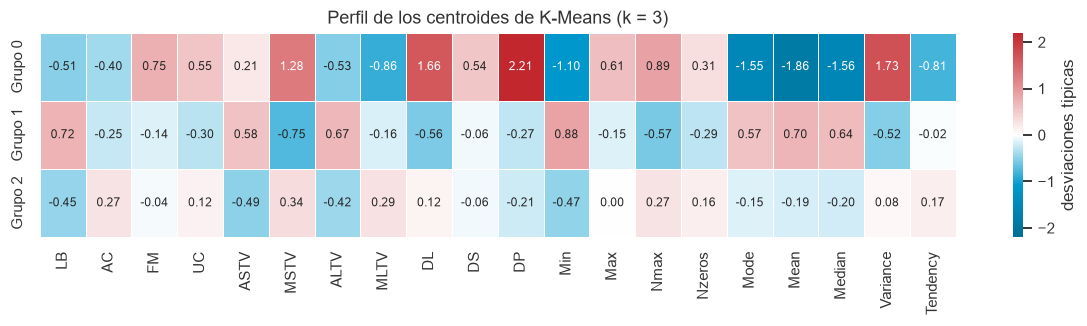


Variables mas caracteristicas de cada grupo:

  Grupo 0 (n = 204): DP +2.21, Mean -1.86, Variance +1.73, DL +1.66, Median -1.56, Mode -1.55
  Grupo 1 (n = 835): Min +0.88, MSTV -0.75, LB +0.72, Mean +0.70, ALTV +0.67, Median +0.64
  Grupo 2 (n = 1087): ASTV -0.49, Min -0.47, LB -0.45, ALTV -0.42, MSTV +0.34, MLTV +0.29


In [24]:
# Celda 6.3. Ajuste final de K-Means y perfilado de los grupos.
# Objetivo: ajustar el modelo definitivo y caracterizar cada grupo. Un
#   agrupamiento sin interpretacion no pasa de ser un vector de numeros: el
#   valor del analisis esta en explicar que distingue a cada grupo.
# Salidas: las etiquetas etq_kmeans, el DataFrame centroides y la figura
#   fig_kmeans_perfil.

K_ELEGIDO = 3
kmeans = KMeans(n_clusters=K_ELEGIDO, n_init=50, random_state=SEMILLA).fit(Z)
etq_kmeans = kmeans.labels_

# Los centroides estan en unidades estandarizadas, de modo que cada valor indica
# cuantas desviaciones tipicas por encima o por debajo de la media general se
# situa el grupo en esa variable.
centroides = pd.DataFrame(kmeans.cluster_centers_, columns=VARIABLES_MODELO)
centroides.index = ["Grupo %d" % i for i in range(K_ELEGIDO)]

tamanos = pd.Series(etq_kmeans).value_counts().sort_index()
print("Tamano de los grupos:")
for i, n in tamanos.items():
    print("  Grupo %d: %4d observaciones (%.1f %%)" % (i, n, 100 * n / len(Z)))
print("\nSilueta global: %.4f" % silhouette_score(Z, etq_kmeans))

plt.figure(figsize=(11, 3.1))
sns.heatmap(centroides, annot=True, fmt=".2f", cmap=CMAP_DIV, center=0,
            vmin=-2.2, vmax=2.2, linewidths=0.4, annot_kws={"size": 8},
            cbar_kws={"label": "desviaciones tipicas"})
plt.title("Perfil de los centroides de K-Means (k = 3)")
plt.tight_layout()
guardar("fig_kmeans_perfil")

print("\nVariables mas caracteristicas de cada grupo:\n")
for g in range(K_ELEGIDO):
    fila = centroides.loc["Grupo %d" % g]
    destacadas = fila.reindex(fila.abs().sort_values(ascending=False).index).head(6)
    texto = ", ".join(["%s %+.2f" % (v, x) for v, x in destacadas.items()])
    print("  Grupo %d (n = %d): %s" % (g, tamanos[g], texto))

RES["tamanos_kmeans"] = {int(i): int(n) for i, n in tamanos.items()}
RES["silueta_kmeans"] = round(float(silhouette_score(Z, etq_kmeans)), 4)
RES["centroides_kmeans"] = centroides.round(2).to_dict("index")

Contingencia (conteos y, entre parentesis, porcentaje por fila):

Diagnostico NSP         Normal    Sospechoso    Patologico
Grupo K-Means                                             
0                  88 (43.1 %)    11 (5.4 %)  105 (51.5 %)
1                 512 (61.3 %)  259 (31.0 %)    64 (7.7 %)
2                1055 (97.1 %)    25 (2.3 %)     7 (0.6 %)

Validacion externa: ARI 0.2142 | NMI 0.2224 | pureza 0.7865
Chi-cuadrado de independencia: 941.4 (gl = 4), p = 1.768e-202
Con p < 0.001, la asociacion con el diagnostico no es atribuible al azar.


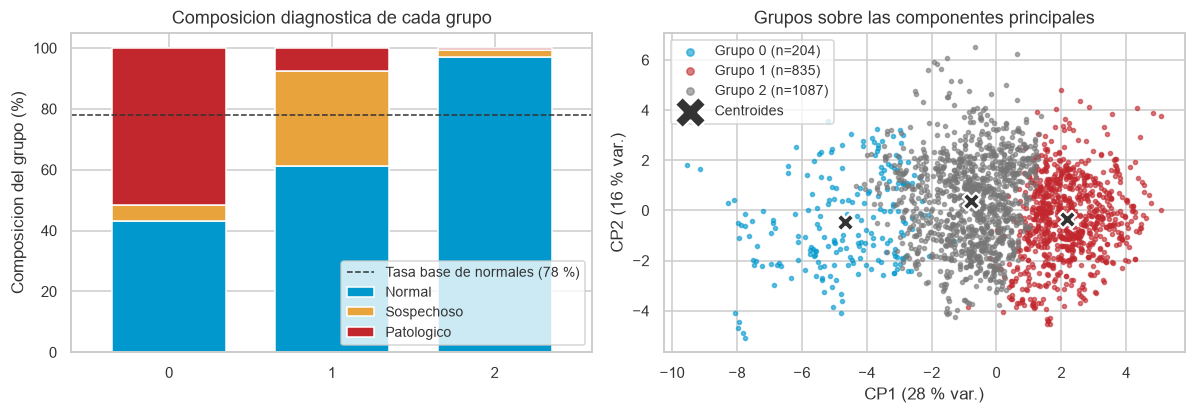

In [25]:
# Celda 6.4. Validacion externa: contraste de los grupos con el diagnostico NSP.
# Objetivo: comprobar si los grupos hallados sin supervision se corresponden con
#   los estados fetales que diagnosticaron los obstetras.
# Salidas: la tabla de contingencia y la figura fig_kmeans_nsp.

NOMBRES_NSP = {1: "Normal", 2: "Sospechoso", 3: "Patologico"}

contingencia = pd.crosstab(
    pd.Series(etq_kmeans, name="Grupo K-Means"),
    pd.Series([NOMBRES_NSP[v] for v in y_nsp], name="Diagnostico NSP"),
)
contingencia = contingencia[["Normal", "Sospechoso", "Patologico"]]
porcentajes = (100 * contingencia.div(contingencia.sum(axis=1), axis=0)).round(1)

print("Contingencia (conteos y, entre parentesis, porcentaje por fila):\n")
print((contingencia.astype(str) + " (" + porcentajes.astype(str) + " %)").to_string())

ari = adjusted_rand_score(y_nsp, etq_kmeans)
nmi = normalized_mutual_info_score(y_nsp, etq_kmeans)
# Pureza: proporcion de aciertos si a cada grupo se le asignara su clase mayoritaria.
pureza = contingencia.max(axis=1).sum() / contingencia.values.sum()
# Prueba chi-cuadrado de independencia entre grupo y diagnostico.
chi2, p_valor, gl, _ = stats.chi2_contingency(contingencia.values)

print("\nValidacion externa: ARI %.4f | NMI %.4f | pureza %.4f" % (ari, nmi, pureza))
print("Chi-cuadrado de independencia: %.1f (gl = %d), p = %.3e" % (chi2, gl, p_valor))
print("Con p < 0.001, la asociacion con el diagnostico no es atribuible al azar.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.9))

porcentajes.plot(kind="bar", stacked=True, ax=a1,
                 color=[UNIR_CIAN, UNIR_AMBAR, UNIR_ROJO], width=0.7)
a1.axhline(100 * (y_nsp == 1).mean(), ls="--", color=UNIR_GRIS_OSC, lw=1,
           label="Tasa base de normales (%.0f %%)" % (100 * (y_nsp == 1).mean()))
a1.set_ylabel("Composicion del grupo (%)")
a1.set_xlabel("")
a1.set_title("Composicion diagnostica de cada grupo")
a1.tick_params(axis="x", rotation=0)
a1.legend(fontsize=9, loc="lower right")

for g in range(K_ELEGIDO):
    m = etq_kmeans == g
    a2.scatter(Z2[m, 0], Z2[m, 1], s=7, alpha=0.6, label="Grupo %d (n=%d)" % (g, m.sum()))
centros_2d = pca.transform(kmeans.cluster_centers_)[:, :2]
a2.scatter(centros_2d[:, 0], centros_2d[:, 1], s=130, marker="X",
           c=UNIR_GRIS_OSC, edgecolor="white", lw=1.5, label="Centroides", zorder=5)
a2.set_xlabel("CP1 (%.0f %% var.)" % (100 * pca.explained_variance_ratio_[0]))
a2.set_ylabel("CP2 (%.0f %% var.)" % (100 * pca.explained_variance_ratio_[1]))
a2.set_title("Grupos sobre las componentes principales")
a2.legend(fontsize=9, markerscale=1.8)
plt.tight_layout()
guardar("fig_kmeans_nsp")

RES["ari_kmeans"] = round(float(ari), 4)
RES["nmi_kmeans"] = round(float(nmi), 4)
RES["pureza_kmeans"] = round(float(pureza), 4)
RES["contingencia_kmeans"] = contingencia.to_dict("index")
RES["porcentajes_kmeans"] = porcentajes.to_dict("index")

In [26]:
# Celda 6.5. Relacion entre los grupos y las anomalias de la seccion 5.
# Objetivo: comprobar si las dos tecnicas, aplicadas de forma independiente,
#   convergen. Si el agrupamiento aisla un grupo minoritario y ese mismo grupo
#   concentra las anomalias de Isolation Forest, ambas estan describiendo la
#   misma estructura subyacente.

cruce = pd.crosstab(
    pd.Series(etq_kmeans, name="Grupo K-Means"),
    pd.Series(np.where(anom_iforest, "Anomalia IF", "Normal IF"), name="Isolation Forest"),
)
cruce_pct = (100 * cruce.div(cruce.sum(axis=1), axis=0)).round(1)

print("Anomalias de Isolation Forest por grupo de K-Means "
      "(tasa global: 5.0 %):\n")
print(pd.DataFrame({"Anomalias": cruce["Anomalia IF"],
                    "Normales": cruce["Normal IF"],
                    "% anomalias": cruce_pct["Anomalia IF"]}).to_string())

RES["anomalias_por_grupo"] = cruce_pct["Anomalia IF"].round(1).to_dict()

Anomalias de Isolation Forest por grupo de K-Means (tasa global: 5.0 %):

               Anomalias  Normales  % anomalias
Grupo K-Means                                  
0                     78       126         38.2
1                      8       827          1.0
2                     21      1066          1.9


El perfilado convierte tres etiquetas numéricas en tres fenotipos clínicos
reconocibles.

El grupo 0, con 204 observaciones y el 9,6 % del conjunto, es el trazado
comprometido: pequeño y extremo. Presenta `DP` en 2,21 y `DL` en 1,66
desviaciones típicas por encima de la media, es decir, abundantes deceleraciones
prolongadas y ligeras; `Variance` en 1,73 y `MSTV` en 1,28, variabilidad
errática; y tendencia central muy baja, con `Mean` en menos 1,86, `Median` en
menos 1,56, `Mode` en menos 1,55 y `Min` en menos 1,10, o sea bradicardia. Su
composición es la más severa, con un 51,5 % de patológicos frente al 8,3 % de
base: este único grupo, menos de una décima parte del conjunto, contiene el 60 %
de todos los casos patológicos, y el 38 % de sus miembros fueron marcados por
Isolation Forest cuando en los otros dos no llega al 2 %.

El grupo 1, con 835 observaciones y el 39,3 %, corresponde a variabilidad
reducida con taquicardia relativa: `LB` en 0,72 y `Min` en 0,88, línea de base
elevada; `ASTV` en 0,58 y `ALTV` en 0,67, mucho tiempo con variabilidad anormal;
y `MSTV` en menos 0,75, variabilidad efectiva baja. Reúne un 61,3 % de normales
pero también un 31,0 % de sospechosos, casi el triple de la tasa base. Es el
grupo de vigilancia.

El grupo 2, con 1 087 observaciones y el 51,1 %, es el trazado tranquilizador:
`AC` en 0,27 y `MLTV` en 0,29, con aceleraciones y buena variabilidad a largo
plazo, junto a `ASTV` en menos 0,49 y `ALTV` en menos 0,42. Un 97,1 % de casos
normales y apenas 7 patológicos.

El índice de Rand ajustado de 0,214 puede parecer modesto, pero la prueba
chi-cuadrado descarta el azar y la contingencia muestra un gradiente monótono de
gravedad. El valor moderado tiene explicación: el agrupamiento separa muy bien
los extremos, los grupos 0 y 2, pero no aísla la categoría de los sospechosos,
que es una zona de transición y no un fenotipo con frontera propia. Que el grupo
más anómalo según K-Means sea también donde se concentran las anomalías de
Isolation Forest refuerza que la estructura hallada es real.

## 6.4 DBSCAN

Espacio de trabajo de DBSCAN: 9 componentes principales (83 % de la varianza)


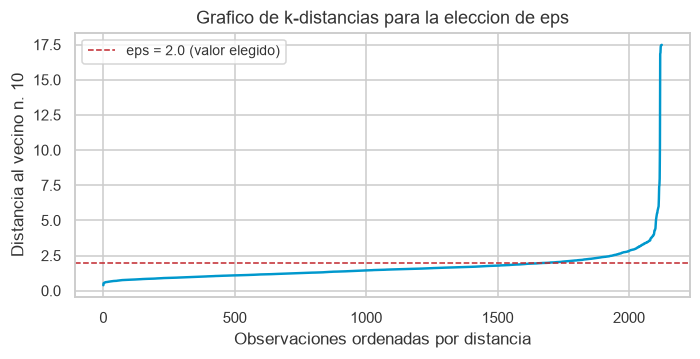


Percentiles de la distancia al vecino n. 10:
  P50 = 1.48
  P75 = 1.88
  P90 = 2.42
  P95 = 2.94
  P99 = 5.14


In [27]:
# Celda 6.6. DBSCAN: eleccion de eps mediante el grafico de k-distancias.
# Objetivo: DBSCAN agrupa regiones densas y etiqueta como ruido, con el valor
#   -1, lo que queda fuera. Necesita dos parametros: min_samples, que es el
#   numero minimo de puntos para considerar densa una zona, y eps, que es el
#   radio del vecindario. El valor de eps se elige con la heuristica de Ester y
#   colaboradores (1996): se ordena la distancia de cada punto a su k-esimo
#   vecino y se busca el codo de la curva resultante.
# Nota: DBSCAN se aplica sobre el espacio reducido por PCA y no sobre las veinte
#   variables originales, porque en dimension alta las distancias se concentran
#   y la nocion de densidad pierde contraste.
# Salidas: la figura fig_dbscan_kdist y el valor EPS_ELEGIDO.

Z_dbscan = Z_pca80
MIN_SAMPLES = 10
print("Espacio de trabajo de DBSCAN:", Z_dbscan.shape[1], "componentes principales",
      "(%.0f %% de la varianza)" % (100 * np.cumsum(pca.explained_variance_ratio_)[Z_dbscan.shape[1] - 1]))

vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z_dbscan)
distancias, _ = vecinos.kneighbors(Z_dbscan)
k_dist = np.sort(distancias[:, -1])

plt.figure(figsize=(6.5, 3.4))
plt.plot(k_dist, lw=1.6, color=UNIR_CIAN)
plt.axhline(2.0, color=UNIR_ROJO, ls="--", lw=1, label="eps = 2.0 (valor elegido)")
plt.xlabel("Observaciones ordenadas por distancia")
plt.ylabel("Distancia al vecino n. %d" % MIN_SAMPLES)
plt.title("Grafico de k-distancias para la eleccion de eps")
plt.legend(fontsize=9)
plt.tight_layout()
guardar("fig_dbscan_kdist")

print("\nPercentiles de la distancia al vecino n. %d:" % MIN_SAMPLES)
for p in [50, 75, 90, 95, 99]:
    print("  P%2d = %.2f" % (p, np.percentile(k_dist, p)))

EPS_ELEGIDO = 2.0

In [28]:
# Celda 6.7. Barrido de parametros y ajuste final de DBSCAN.
# Objetivo: explorar la sensibilidad de DBSCAN al par (eps, min_samples) y
#   ajustar el modelo definitivo. La silueta se calcula excluyendo el ruido,
#   porque los puntos etiquetados con -1 no constituyen un grupo.
# Salidas: las etiquetas etq_dbscan y el DataFrame barrido_dbscan.

registros = []
for eps in [1.6, 1.8, 2.0, 2.2, 2.5, 3.0]:
    for ms in [10, 16, 20]:
        etiquetas = DBSCAN(eps=eps, min_samples=ms).fit_predict(Z_dbscan)
        n_grupos = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_ruido = int((etiquetas == -1).sum())
        # La silueta requiere al menos dos grupos entre los puntos no ruidosos.
        if n_grupos > 1:
            sil = silhouette_score(Z_dbscan[etiquetas != -1], etiquetas[etiquetas != -1])
        else:
            sil = np.nan
        registros.append({
            "eps": eps, "min_samples": ms, "Grupos": n_grupos,
            "Ruido": n_ruido, "% ruido": round(100 * n_ruido / len(Z), 1),
            "Silueta (sin ruido)": round(sil, 4) if not np.isnan(sil) else None,
            "ARI vs NSP": round(adjusted_rand_score(y_nsp, etiquetas), 4),
        })

barrido_dbscan = pd.DataFrame(registros)

# De las 18 combinaciones se imprimen solo las que llegan a formar mas de un
# grupo, porque son las unicas comparables; de las demas basta con saber cuantas
# son, ya que todas devuelven un unico grupo mas ruido.
un_solo_grupo = int((barrido_dbscan["Grupos"] <= 1).sum())
print("Sensibilidad de DBSCAN: de las %d combinaciones probadas, %d devuelven un"
      % (len(barrido_dbscan), un_solo_grupo))
print("unico grupo mas ruido. Las %d restantes son:\n"
      % (len(barrido_dbscan) - un_solo_grupo))
print(barrido_dbscan[barrido_dbscan["Grupos"] > 1].to_string(index=False))

dbscan = DBSCAN(eps=EPS_ELEGIDO, min_samples=MIN_SAMPLES)
etq_dbscan = dbscan.fit_predict(Z_dbscan)

n_grupos_db = len(set(etq_dbscan)) - (1 if -1 in etq_dbscan else 0)
ruido_db = etq_dbscan == -1

tamanos_db = ", ".join(
    "%s: %d" % ("ruido" if g == -1 else "grupo %d" % g, (etq_dbscan == g).sum())
    for g in sorted(set(etq_dbscan)))
print("\nDBSCAN definitivo (eps = %.1f, min_samples = %d): %d grupos y %d puntos "
      "de ruido (%.1f %%)"
      % (EPS_ELEGIDO, MIN_SAMPLES, n_grupos_db, ruido_db.sum(), 100 * ruido_db.mean()))
print("  Tamanos -> %s" % tamanos_db)

RES["dbscan_n_grupos"] = int(n_grupos_db)
RES["dbscan_ruido"] = int(ruido_db.sum())
RES["barrido_dbscan"] = barrido_dbscan.to_dict("records")

Sensibilidad de DBSCAN: de las 18 combinaciones probadas, 11 devuelven un
unico grupo mas ruido. Las 7 restantes son:

 eps  min_samples  Grupos  Ruido  % ruido  Silueta (sin ruido)  ARI vs NSP
 1.8           10       2    300     14.1               0.3936      0.1597
 2.0           10       2    213     10.0               0.3874      0.1965
 2.0           16       2    268     12.6               0.3747      0.1784
 2.2           10       2    139      6.5               0.3837      0.2047
 2.2           16       2    178      8.4               0.3666      0.2116
 2.2           20       2    203      9.5               0.3683      0.2003
 3.0           10       2     38      1.8               0.4471      0.0705

DBSCAN definitivo (eps = 2.0, min_samples = 10): 2 grupos y 213 puntos de ruido (10.0 %)
  Tamanos -> ruido: 213, grupo 0: 1885, grupo 1: 28


Contingencia DBSCAN frente a NSP (conteos y, entre parentesis, porcentaje por fila):

Diagnostico NSP         Normal    Sospechoso    Patologico
DBSCAN                                                    
Grupo 0          1537 (81.5 %)  272 (14.4 %)    76 (4.0 %)
Grupo 1              0 (0.0 %)     0 (0.0 %)  28 (100.0 %)
Ruido             118 (55.4 %)   23 (10.8 %)   72 (33.8 %)

Validacion externa: ARI = 0.1965 | NMI = 0.1340

Coincidencia entre el ruido de DBSCAN y las anomalias de Isolation Forest:
  Indice de Jaccard: 0.455
  Puntos marcados por ambos metodos: 100


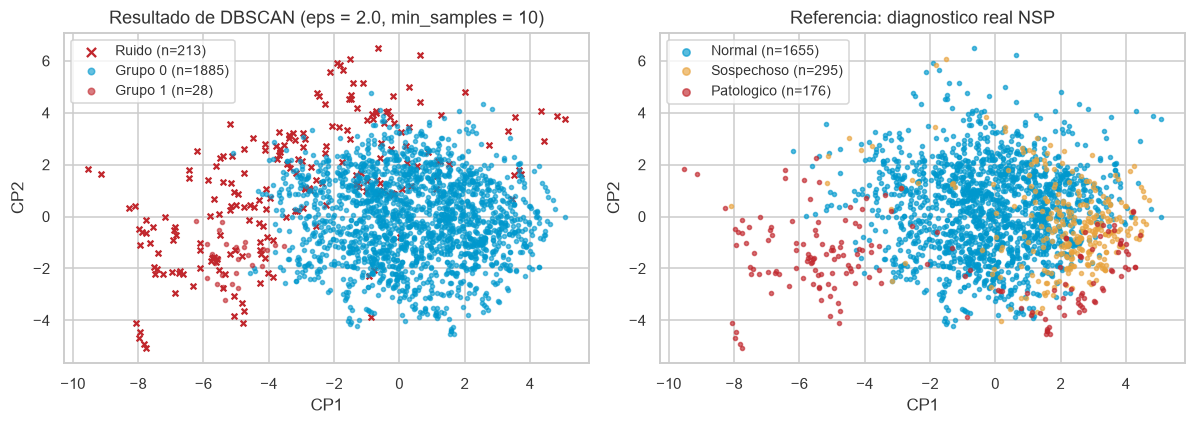

In [29]:
# Celda 6.8. Interpretacion de la salida de DBSCAN.
# Objetivo: contrastar los grupos y el ruido de DBSCAN con el diagnostico NSP y
#   con las anomalias de Isolation Forest.
# Salidas: las tablas impresas y la figura fig_dbscan.

etiquetas_legibles = ["Ruido" if g == -1 else "Grupo %d" % g for g in etq_dbscan]
cont_db = pd.crosstab(
    pd.Series(etiquetas_legibles, name="DBSCAN"),
    pd.Series([NOMBRES_NSP[v] for v in y_nsp], name="Diagnostico NSP"),
)[["Normal", "Sospechoso", "Patologico"]]

pct_db = (100 * cont_db.div(cont_db.sum(axis=1), axis=0)).round(1)
print("Contingencia DBSCAN frente a NSP "
      "(conteos y, entre parentesis, porcentaje por fila):\n")
print((cont_db.astype(str) + " (" + pct_db.astype(str) + " %)").to_string())

print("\nValidacion externa: ARI = %.4f | NMI = %.4f"
      % (adjusted_rand_score(y_nsp, etq_dbscan),
         normalized_mutual_info_score(y_nsp, etq_dbscan)))

jaccard_ruido = (ruido_db & anom_iforest).sum() / (ruido_db | anom_iforest).sum()
print("\nCoincidencia entre el ruido de DBSCAN y las anomalias de Isolation Forest:")
print("  Indice de Jaccard: %.3f" % jaccard_ruido)
print("  Puntos marcados por ambos metodos: %d" % (ruido_db & anom_iforest).sum())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))

for g in sorted(set(etq_dbscan)):
    m = etq_dbscan == g
    if g == -1:
        a1.scatter(Z2[m, 0], Z2[m, 1], s=14, c=UNIR_ROJO, marker="x",
                   label="Ruido (n=%d)" % m.sum())
    else:
        a1.scatter(Z2[m, 0], Z2[m, 1], s=7, alpha=0.6, label="Grupo %d (n=%d)" % (g, m.sum()))
a1.set_xlabel("CP1"); a1.set_ylabel("CP2")
a1.set_title("Resultado de DBSCAN (eps = %.1f, min_samples = %d)" % (EPS_ELEGIDO, MIN_SAMPLES))
a1.legend(fontsize=9, markerscale=1.6)

colores_nsp = {1: UNIR_CIAN, 2: UNIR_AMBAR, 3: UNIR_ROJO}
for v in [1, 2, 3]:
    m = y_nsp == v
    a2.scatter(Z2[m, 0], Z2[m, 1], s=7, alpha=0.65, c=colores_nsp[v],
               label="%s (n=%d)" % (NOMBRES_NSP[v], m.sum()))
a2.set_xlabel("CP1"); a2.set_ylabel("CP2")
a2.set_title("Referencia: diagnostico real NSP")
a2.legend(fontsize=9, markerscale=1.8)
plt.tight_layout()
guardar("fig_dbscan")

RES["dbscan_ari"] = round(float(adjusted_rand_score(y_nsp, etq_dbscan)), 4)
RES["jaccard_ruido_if"] = round(float(jaccard_ruido), 3)

DBSCAN no produce una partición útil, y el motivo es informativo. Encuentra dos
grupos y 213 puntos de ruido con un reparto radicalmente asimétrico: un grupo
absorbe 1 885 observaciones, el 88,7 % del conjunto, y el otro apenas 28.

El barrido demuestra que es estructural y no una mala elección de eps: en once de
las dieciocho combinaciones probadas devuelve un único grupo más ruido, y en las
siete restantes el segundo nunca supera unas decenas de puntos. Los datos no
tienen zonas de baja densidad que separen regiones densas, sino una nube única
cuya densidad decae de forma continua hacia la periferia. DBSCAN necesita valles
y aquí no los hay.

Ahora bien, el grupo 1, de 28 observaciones, está compuesto íntegramente por
casos patológicos: ha aislado un fenotipo extremo con precisión perfecta, aunque
cubre solo el 16 % de los patológicos. El ruido también informa: de los 213
puntos etiquetados con menos uno, el 33,8 % son patológicos, cuatro veces la tasa
base, y su índice de Jaccard con las anomalías de Isolation Forest es de 0,455,
compartiendo 100 puntos, la concordancia más alta entre dos métodos de todo el
trabajo.

En este conjunto DBSCAN rinde mejor como detector de anomalías que como
algoritmo de agrupamiento. Su índice de Rand ajustado global, 0,197, es
comparable al de K-Means, pero se consigue por otra vía: no por particionar bien
sino por apartar los casos extremos. Coherentemente, su información mutua
normalizada, 0,134, es muy inferior a la de K-Means, 0,222, porque deja el 88,7 %
de los registros en un grupo indiferenciado.

## 6.5 Agrupamiento jerárquico aglomerativo

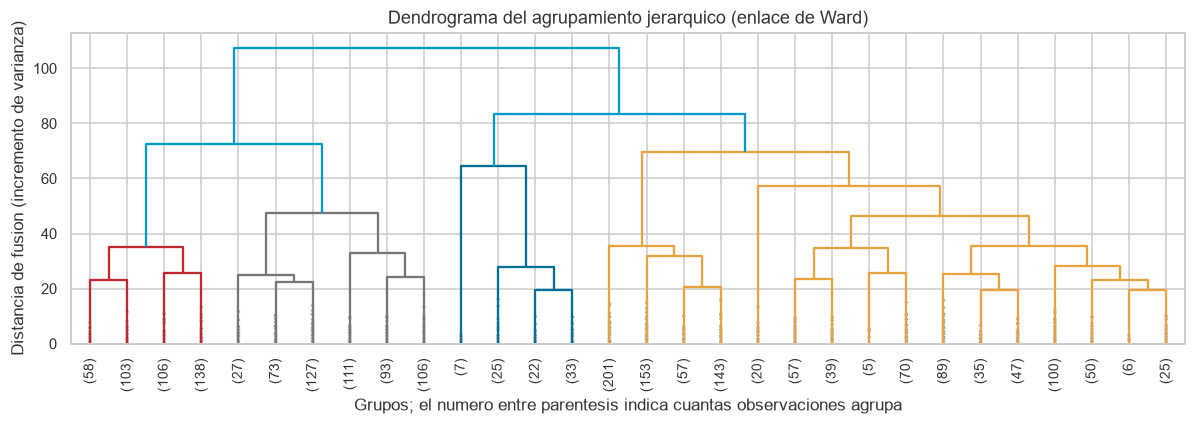

Comparacion de criterios de enlace con k = 3:

                  Tamanos  Grupo mayor (%)  Silueta  ARI vs NSP
Enlace                                                         
ward      1097 / 942 / 87             51.6   0.1348      0.1793
average      2114 / 7 / 5             99.4   0.5188      0.0187
complete     2116 / 7 / 3             99.5   0.5749      0.0202

Los enlaces average y complete logran siluetas muy superiores a ward,
pero dejando mas del 99 % de las observaciones en un unico grupo. Una
silueta alta con una particion degenerada NO indica un buen agrupamiento.

Ward definitivo (k = 3): tamanos [942, 1097, 87], silueta 0.1348
  ARI frente a NSP 0.1793 | ARI frente a K-Means 0.3711 (concordancia)


In [30]:
# Celda 6.9. Agrupamiento jerarquico: dendrograma y criterios de enlace.
# Objetivo: construir la jerarquia completa de fusiones y comparar tres
#   criterios de enlace. El dendrograma permite decidir el numero de grupos a
#   posteriori, observando a que altura se producen las fusiones mas costosas.
# Salidas: la figura fig_dendrograma, las etiquetas etq_jerarquico y el
#   DataFrame comparacion_enlaces.

# linkage() de SciPy calcula la jerarquia completa. El metodo de Ward minimiza
# el incremento de varianza intragrupo en cada fusion, que es el criterio mas
# proximo al que emplea K-Means.
matriz_enlace = linkage(Z, method="ward")

plt.figure(figsize=(11, 4.0))
dendrogram(matriz_enlace, truncate_mode="lastp", p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True, color_threshold=70)
plt.title("Dendrograma del agrupamiento jerarquico (enlace de Ward)")
plt.xlabel("Grupos; el numero entre parentesis indica cuantas observaciones agrupa")
plt.ylabel("Distancia de fusion (incremento de varianza)")
plt.tight_layout()
guardar("fig_dendrograma")

# Comparacion de criterios de enlace. Se comprueba una advertencia clasica: los
# enlaces average y complete pueden producir particiones degeneradas con
# siluetas enganosamente altas.
filas = []
for enlace in ["ward", "average", "complete"]:
    etiquetas = AgglomerativeClustering(n_clusters=3, linkage=enlace).fit_predict(Z)
    tam = np.bincount(etiquetas)
    filas.append({
        "Enlace": enlace,
        "Tamanos": " / ".join(str(t) for t in sorted(tam, reverse=True)),
        "Grupo mayor (%)": round(100 * tam.max() / len(Z), 1),
        "Silueta": round(silhouette_score(Z, etiquetas), 4),
        "ARI vs NSP": round(adjusted_rand_score(y_nsp, etiquetas), 4),
    })

comparacion_enlaces = pd.DataFrame(filas).set_index("Enlace")
print("Comparacion de criterios de enlace con k = 3:\n")
print(comparacion_enlaces.to_string())
print("\nLos enlaces average y complete logran siluetas muy superiores a ward,")
print("pero dejando mas del 99 % de las observaciones en un unico grupo. Una")
print("silueta alta con una particion degenerada NO indica un buen agrupamiento.")

jerarquico = AgglomerativeClustering(n_clusters=3, linkage="ward")
etq_jerarquico = jerarquico.fit_predict(Z)

print("\nWard definitivo (k = 3): tamanos %s, silueta %.4f"
      % (np.bincount(etq_jerarquico).tolist(), silhouette_score(Z, etq_jerarquico)))
print("  ARI frente a NSP %.4f | ARI frente a K-Means %.4f (concordancia)"
      % (adjusted_rand_score(y_nsp, etq_jerarquico),
         adjusted_rand_score(etq_kmeans, etq_jerarquico)))

RES["comparacion_enlaces"] = comparacion_enlaces.reset_index().to_dict("records")
RES["ari_jerarquico"] = round(float(adjusted_rand_score(y_nsp, etq_jerarquico)), 4)
RES["ari_kmeans_vs_jerarquico"] = round(float(adjusted_rand_score(etq_kmeans, etq_jerarquico)), 4)

El dendrograma muestra un salto de altura claro en las últimas fusiones,
compatible con dos o tres grupos, lo que respalda la elección de k igual a 3.

La comparación de criterios de enlace produce el aviso metodológico más
importante de la sección. Los enlaces `average` y `complete` obtienen siluetas de
0,52 y 0,57, hasta cuatro veces mejores que las de Ward, que se queda en 0,13,
pero lo consiguen dejando más del 99 % de las observaciones en un solo grupo y
aislando dos grupitos de entre 3 y 7 puntos, con índices de Rand prácticamente
nulos, de 0,02. Es la ilustración de que una métrica interna alta puede
corresponder a un modelo inservible: la silueta premia particiones donde casi
todo está junto y unos pocos puntos alejados forman grupos triviales.

Con Ward la partición es equilibrada, con 1 097, 942 y 87 observaciones, y su
índice de Rand frente a `NSP` es de 0,179, algo inferior al 0,214 de K-Means.
Curiosamente su información mutua normalizada es algo superior, 0,230 frente a
0,222: Ward capta algo más de información sobre el diagnóstico pero la reparte
peor entre los grupos, que es lo que penaliza el índice de Rand. La concordancia
entre ambas particiones es de 0,371, de modo que coinciden en lo esencial pero no
son intercambiables, sobre todo en la frontera entre los dos grupos grandes.

## 6.6 Comparación global de los tres algoritmos

COMPARACION FINAL DE LOS ALGORITMOS DE AGRUPAMIENTO

                       Grupos  Sin asignar  Silueta  Davies-Bouldin  ARI vs NSP  NMI vs NSP Requiere k Detecta ruido
Algoritmo                                                                                                           
K-Means (k=3)               3            0   0.1572          1.9233      0.2142      0.2224         Si            No
DBSCAN (eps=2.0)            2          213   0.3874          0.7396      0.1965      0.1340         No            Si
Jerarquico Ward (k=3)       3            0   0.1348          2.0230      0.1793      0.2297         Si            No


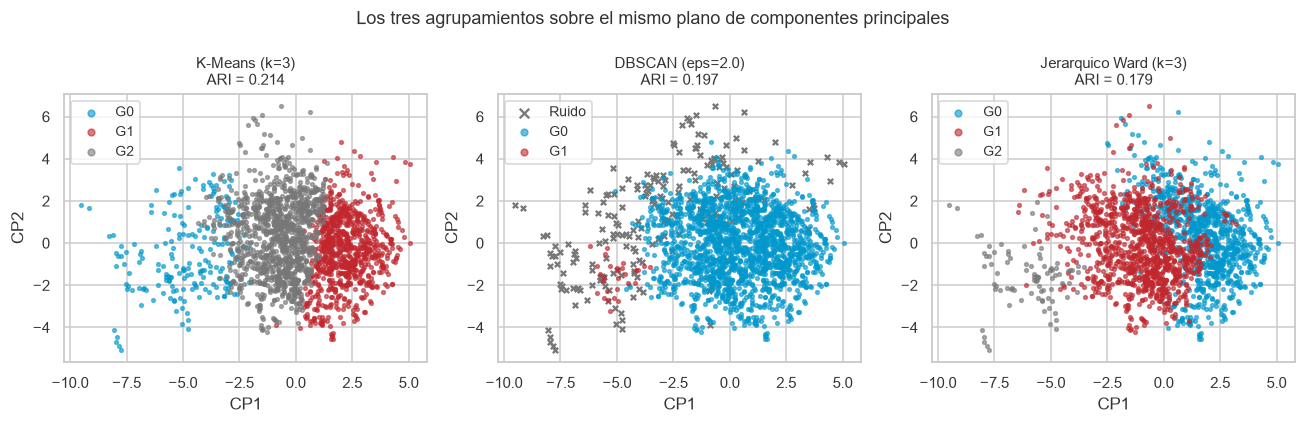

In [31]:
# Celda 6.10. Comparacion final de los tres algoritmos de agrupamiento.
# Objetivo: reunir en una sola tabla y en una sola figura los resultados de
#   K-Means, DBSCAN y jerarquico, con metricas internas y externas.
# Salidas: el DataFrame tabla_clustering y la figura fig_clustering_comparacion.

def evaluar_agrupamiento(nombre, etiquetas, espacio, requiere_k, maneja_ruido):
    """Calcula el bloque de metricas de un agrupamiento.

    El ruido, con etiqueta -1, se excluye de las metricas internas, ya que por
    definicion no constituye un grupo; si se incluyera penalizaria de forma
    artificial a DBSCAN frente a los algoritmos que particionan todo.
    """
    validos = etiquetas != -1
    n_grupos = len(set(etiquetas[validos]))
    sil = silhouette_score(espacio[validos], etiquetas[validos]) if n_grupos > 1 else np.nan
    db = davies_bouldin_score(espacio[validos], etiquetas[validos]) if n_grupos > 1 else np.nan
    return {
        "Algoritmo": nombre,
        "Grupos": n_grupos,
        "Sin asignar": int((~validos).sum()),
        "Silueta": round(sil, 4) if not np.isnan(sil) else None,
        "Davies-Bouldin": round(db, 4) if not np.isnan(db) else None,
        "ARI vs NSP": round(adjusted_rand_score(y_nsp, etiquetas), 4),
        "NMI vs NSP": round(normalized_mutual_info_score(y_nsp, etiquetas), 4),
        "Requiere k": "Si" if requiere_k else "No",
        "Detecta ruido": "Si" if maneja_ruido else "No",
    }


tabla_clustering = pd.DataFrame([
    evaluar_agrupamiento("K-Means (k=3)", etq_kmeans, Z, True, False),
    evaluar_agrupamiento("DBSCAN (eps=2.0)", etq_dbscan, Z_dbscan, False, True),
    evaluar_agrupamiento("Jerarquico Ward (k=3)", etq_jerarquico, Z, True, False),
]).set_index("Algoritmo")

print("COMPARACION FINAL DE LOS ALGORITMOS DE AGRUPAMIENTO\n")
print(tabla_clustering.to_string())

fig, ejes = plt.subplots(1, 3, figsize=(12, 3.9))
particiones = [
    ("K-Means (k=3)", etq_kmeans),
    ("DBSCAN (eps=2.0)", etq_dbscan),
    ("Jerarquico Ward (k=3)", etq_jerarquico),
]
for eje, (nombre, etiquetas) in zip(ejes, particiones):
    for g in sorted(set(etiquetas)):
        m = etiquetas == g
        if g == -1:
            eje.scatter(Z2[m, 0], Z2[m, 1], s=12, c=UNIR_GRIS, marker="x", label="Ruido")
        else:
            eje.scatter(Z2[m, 0], Z2[m, 1], s=6, alpha=0.6, label="G%d" % g)
    eje.set_title("%s\nARI = %.3f" % (nombre, tabla_clustering.loc[nombre, "ARI vs NSP"]), fontsize=10)
    eje.set_xlabel("CP1"); eje.set_ylabel("CP2")
    eje.legend(fontsize=9, markerscale=1.8)
fig.suptitle("Los tres agrupamientos sobre el mismo plano de componentes principales", fontsize=12)
plt.tight_layout()
guardar("fig_clustering_comparacion")

RES["tabla_clustering"] = tabla_clustering.reset_index().to_dict("records")

# 7. Ventajas y desventajas de cada modelo

## 7.1 Modelos de detección de anomalías

El Z-score es trivial de calcular e interpretar y su umbral tiene significado
probabilístico directo. En contra: asume normalidad, es univariante e ignora las
correlaciones, y su error acumulado crece con el número de columnas. Marcó el
16,1 % de las observaciones y, pese a un lift de 4,90, lo hizo a costa de
demasiados falsos positivos.

La regla de Tukey no asume distribución, es robusta frente a valores extremos y
es la base del diagrama de caja. Pero también es univariante y resulta
inservible con fuerte asimetría o exceso de ceros, que es lo que ocurre aquí:
marcó el 57,4 % con un lift de 1,65, de manera que no discrimina.

La distancia de Mahalanobis robusta es multivariante, tiene en cuenta la
covarianza y su estimador de determinante mínimo evita el enmascaramiento que
padecen la media y la covarianza muestrales. A cambio exige covarianza
invertible, requisito que obligó a eliminar `Width`, asume normalidad
multivariante y su coste crece de forma cúbica con el número de variables.
Obtuvo un lift de 5,01 al 5 %, aunque el gráfico cuantil-cuantil dejó claro que
su supuesto no se cumple.

Isolation Forest no asume distribución, su coste es lineal, escala bien en
dimensión alta y tiene pocos hiperparámetros. En contra: la contaminación debe
fijarse a priori, el resultado varía con la semilla y sus cortes son paralelos a
los ejes, lo que dificulta detectar estructuras oblicuas. Fue el mejor, con lift
de 6,55, un 54,2 % de patológicos entre los marcados y un recall del 33 %.

El factor local de atipicidad es el único capaz de detectar anomalías locales y
no impone forma global. En contra, la altísima sensibilidad al número de vecinos,
la degradación de la densidad en dimensión alta y la imposibilidad de generalizar
a datos nuevos sin activar el modo de novedad. Fue el peor de los
multivariantes, con lift de 2,14.

## 7.2 Modelos de agrupamiento

K-Means es rápido y escalable, produce grupos interpretables mediante sus
centroides y converge siempre. A cambio exige fijar el número de grupos, los
supone esféricos y de tamaño similar, sus centroides no son robustos frente a
atípicos y solo garantiza óptimos locales. Fue el mejor de los tres, con índice
de Rand ajustado de 0,214 y tres fenotipos clínicamente coherentes.

DBSCAN no exige fijar el número, admite formas arbitrarias e identifica el ruido
de manera explícita. Sus desventajas: enorme sensibilidad a eps y min_samples,
fracaso cuando la densidad varía de forma continua y degradación en dimensión
alta. Produjo dos grupos muy desiguales, de 1 885 y 28 observaciones, más 213
puntos de ruido, con índice de 0,197; útil como detector pero no como partición.

El jerárquico produce la jerarquía completa, de modo que el número de grupos se
decide después, su dendrograma es muy interpretable y el resultado es
determinista. En contra, el coste cuadrático en memoria y tiempo, la
imposibilidad de deshacer una fusión y la fuerte dependencia del criterio de
enlace. Con Ward obtuvo 0,179, mientras que `average` y `complete` degeneraron
pese a siluetas mucho más altas.

## 7.3 Síntesis metodológica

De la comparación se desprenden tres lecciones. Las métricas internas no bastan:
la silueta escogía dos grupos en K-Means, partición con índice de Rand de 0,016,
y premiaba los enlaces degenerados del jerárquico con 0,52 y 0,57 pese a dejar el
99 % de los datos en un solo grupo. Sin referencia externa ni conocimiento del
dominio, esos criterios habrían llevado a conclusiones erróneas.

Los supuestos distribucionales importan más que la sofisticación del método: los
dos algoritmos que no asumen ninguna distribución, Isolation Forest y K-Means,
fueron los mejores de su categoría, y en un conjunto fuertemente asimétrico.

Y la convergencia entre técnicas independientes es la mejor evidencia
disponible. El grupo 0 de K-Means, el grupo 1 y el ruido de DBSCAN, y las
anomalías de Isolation Forest apuntan al mismo subconjunto de trazados: tres
algoritmos con criterios distintos coinciden porque hay una estructura real que
describir.

# 8. Conclusiones

In [32]:
# Celda 8.1. Resumen ejecutivo de resultados y volcado a disco.
# Objetivo: recapitular las cifras clave y guardar todos los resultados en
#   resultados.json, que es la fuente unica desde la que se genera el informe en
#   PDF. De este modo ninguna cifra del informe se transcribe a mano y no puede
#   desincronizarse del codigo.
# Salidas: el archivo resultados.json.

print("RESUMEN EJECUTIVO\n")
mejor = max(RES["tabla_anomalias"], key=lambda r: r["Lift"])
print("Datos      : %d registros analizados (de %d en el archivo), %d variables"
      % (RES["n_filas_final"],
         RES["n_filas_final"] + RES["n_filas_eliminadas"],
         RES["n_variables_modelo"]))
print("             %d filas eliminadas por ser filas de resumen de la hoja"
      % RES["n_filas_eliminadas"])
print("\nAnomalias  : Isolation Forest al 5 %%, %d observaciones marcadas"
      % mejor["Marcadas"])
print("             %.1f %% patologicos (tasa base %.1f %%), lift %.2f, recall %.1f %%"
      % (mejor["% patologicos"], 100 * RES["tasa_base_nsp3"],
         mejor["Lift"], mejor["Recall NSP=3"]))
print("\nAgrupamiento: K-Means con k = 3, grupos de %s observaciones"
      % " / ".join(str(v) for v in RES["tamanos_kmeans"].values()))
print("             silueta %.4f | ARI %.4f | NMI %.4f | pureza %.4f"
      % (RES["silueta_kmeans"], RES["ari_kmeans"],
         RES["nmi_kmeans"], RES["pureza_kmeans"]))


def convertir(objeto):
    """Convierte tipos de NumPy a tipos nativos serializables por json."""
    if isinstance(objeto, (np.integer,)):
        return int(objeto)
    if isinstance(objeto, (np.floating,)):
        return float(objeto)
    if isinstance(objeto, np.ndarray):
        return objeto.tolist()
    return str(objeto)


with open("resultados.json", "w", encoding="utf-8") as fh:
    json.dump(RES, fh, ensure_ascii=False, indent=2, default=convertir)

print("\nResultados guardados en 'resultados.json' (%d claves)." % len(RES))
print("Figuras guardadas en '%s/' (%d archivos)."
      % (DIR_FIGURAS, len(list(DIR_FIGURAS.glob("*.png")))))

RESUMEN EJECUTIVO

Datos      : 2126 registros analizados (de 2129 en el archivo), 20 variables
             3 filas eliminadas por ser filas de resumen de la hoja

Anomalias  : Isolation Forest al 5 %, 107 observaciones marcadas
             54.2 % patologicos (tasa base 8.3 %), lift 6.55, recall 33.0 %

Agrupamiento: K-Means con k = 3, grupos de 204 / 835 / 1087 observaciones
             silueta 0.1572 | ARI 0.2142 | NMI 0.2224 | pureza 0.7865

Resultados guardados en 'resultados.json' (42 claves).
Figuras guardadas en 'figuras/' (15 archivos).


## 8.1 Sobre el análisis exploratorio

El análisis exploratorio no fue un trámite previo sino que determinó todas las
decisiones posteriores: descubrió que las tres últimas filas eran artefactos y no
pacientes; que `LBE` duplica a `LB`, que `DR` es constante y que `Width` equivale
exactamente a la diferencia entre `Max` y `Min`, redundancia que hacía singular
la matriz de covarianzas e impedía calcular la distancia de Mahalanobis; y que
las diez variables entre `A` y `SUSP` recodifican `CLASS`. De las 40 columnas
iniciales solo 20 son descriptores genuinos.

El estudio de las distribuciones reveló asimetrías extremas y colas pesadas, lo
que permitió anticipar y después confirmar que los métodos basados en normalidad
rendirían peor que los no paramétricos.

## 8.2 Sobre el tratamiento de los valores faltantes

La respuesta correcta no consistía en elegir entre la media, la mediana o la
moda, sino en reconocer que las filas afectadas no eran observaciones. Las 106
celdas faltantes se concentraban en 3 filas sin diagnóstico que resultaron ser
las filas de resumen de la hoja de cálculo original: una de mínimos y otra que
reproduce el máximo de cada columna, coincidencia comprobada variable a
variable. Imputarlas con la media habría fabricado tres pacientes ficticios, uno
de los cuales alcanzaría a la vez el valor extremo de diez variables distintas,
combinación que no se da en ningún trazado real, y habría contaminado tanto la
detección de anomalías como los centroides de K-Means.

El experimento del apartado 3.3 responde a la pregunta general: cuando los
faltantes son reales y dispersos, la mejor estrategia es la imputación por
vecinos más cercanos, porque aprovecha la correlación entre variables, y la
mediana es la mejor alternativa simple para las sesgadas. La media, que suele
aplicarse por costumbre, distorsiona la forma de las distribuciones asimétricas,
y la moda es la peor opción para variables continuas.

## 8.3 Sobre la detección de anomalías

Isolation Forest es el método elegido. Marcando solo el 5 % de los registros, el
54,2 % de los señalados resultaron patológicos frente a una tasa base del 8,3 %:
un enriquecimiento de 6,6 veces y la recuperación de un tercio de los casos
graves. Su perfil medio, con deceleraciones prolongadas y severas, variabilidad
errática y bradicardia, reproduce la descripción clínica de un trazado no
tranquilizador sin haber visto un solo diagnóstico.

Los métodos univariantes quedaron descartados por marcar el 16 % y el 57 % del
conjunto. El factor local de atipicidad, pese a su sofisticación teórica, fue el
peor de los multivariantes, porque en veinte dimensiones la densidad local pierde
contraste y porque los casos patológicos no son puntos aislados sino una región
periférica poblada que el método toma por un vecindario legítimo.

El bajo solapamiento entre métodos, con índices de Jaccard de 0,07 a 0,37,
demuestra que ser una anomalía es una noción relativa al método. Elegir detector
exige un criterio externo de utilidad; sin él la elección sería arbitraria.

## 8.4 Sobre el agrupamiento

K-Means con tres grupos es el modelo elegido, con índice de Rand ajustado de
0,214 frente a `NSP` y una prueba chi-cuadrado que descarta el azar. Los grupos
admiten lectura clínica directa: uno tranquilizador de 1 087 registros con un
97,1 % de normales, otro de vigilancia de 835 registros con un 31 % de
sospechosos y otro comprometido de 204 registros con un 51,5 % de patológicos,
que concentra el 60 % de todos los casos graves.

DBSCAN no logró una partición útil porque los datos forman una nube única de
densidad decreciente, sin los valles que necesita; aun así aisló un grupo de 28
casos íntegramente patológicos y su ruido coincide en un 46 %, por índice de
Jaccard, con las anomalías de Isolation Forest. El jerárquico con Ward produjo
una partición equilibrada y coherente, con 0,179, mientras que `average` y
`complete` degeneraron pese a siluetas mucho más altas.

El valor moderado de todos los índices tiene explicación sustantiva y no
metodológica: los algoritmos separan bien los extremos, pero la categoría de los
sospechosos es una zona de transición y no un fenotipo con frontera propia.
Ningún método no supervisado puede recuperar una categoría que no forma grupo en
el espacio de características.

## 8.5 Conclusión general

El aprendizaje no supervisado recupera estructura clínicamente válida en los
datos de cardiotocografía: sin acceder a ningún diagnóstico, los algoritmos
identificaron el subconjunto de trazados comprometidos y un gradiente de gravedad
coherente con la clasificación obstétrica.

La conclusión práctica es que ambas técnicas son complementarias y no
alternativas. Isolation Forest responde a qué registros concretos revisar con
prioridad y K-Means a qué tipos de trazado existen en la población; un sistema de
apoyo a la decisión clínica se beneficiaría de las dos, el agrupamiento para
estratificar y la detección de anomalías para priorizar la revisión individual.

La lección metodológica de mayor alcance es que la calidad de un modelo no
supervisado no puede juzgarse solo con métricas internas. En dos ocasiones el
coeficiente de silueta habría conducido a la peor decisión posible: al elegir dos
grupos en K-Means y al preferir los enlaces degenerados del jerárquico. El
conocimiento del dominio y una referencia externa, cuando existe, son
insustituibles.

# Referencias

Ayres-de-Campos, D., Bernardes, J., Garrido, A., Marques-de-Sá, J., &
Pereira-Leite, L. (2000). SisPorto 2.0: A program for automated analysis of
cardiotocograms. *Journal of Maternal-Fetal Medicine, 9*(5), 311-318.
https://doi.org/10.1002/1520-6661(200009/10)9:5<311::AID-MFM12>3.0.CO;2-9

Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF:
Identifying density-based local outliers. *Proceedings of the 2000 ACM SIGMOD
International Conference on Management of Data*, 93-104.
https://doi.org/10.1145/342009.335388

Calinski, T., & Harabasz, J. (1974). A dendrite method for cluster analysis.
*Communications in Statistics, 3*(1), 1-27.
https://doi.org/10.1080/03610927408827101

Davies, D. L., & Bouldin, D. W. (1979). A cluster separation measure. *IEEE
Transactions on Pattern Analysis and Machine Intelligence, PAMI-1*(2), 224-227.
https://doi.org/10.1109/TPAMI.1979.4766909

Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). A density-based
algorithm for discovering clusters in large spatial databases with noise.
*Proceedings of the Second International Conference on Knowledge Discovery and
Data Mining (KDD-96)*, 226-231.

Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of
Classification, 2*(1), 193-218. https://doi.org/10.1007/BF01908075

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *2008 Eighth
IEEE International Conference on Data Mining*, 413-422.
https://doi.org/10.1109/ICDM.2008.17

Meneses Yaranga, A. (2026). *Actividad de Aprendizaje Automático: detección de
anomalías y técnicas de agrupamiento sobre el conjunto de datos CTG* [Código
fuente]. GitHub. https://github.com/amenesesy/actividad-ml-ctg

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos,
A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research,
12*, 2825-2830.

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and
validation of cluster analysis. *Journal of Computational and Applied
Mathematics, 20*, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7

Rousseeuw, P. J., & Van Driessen, K. (1999). A fast algorithm for the minimum
covariance determinant estimator. *Technometrics, 41*(3), 212-223.
https://doi.org/10.1080/00401706.1999.10485670

Rubin, D. B. (1976). Inference and missing data. *Biometrika, 63*(3), 581-592.
https://doi.org/10.1093/biomet/63.3.581

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

Ward, J. H. (1963). Hierarchical grouping to optimize an objective function.
*Journal of the American Statistical Association, 58*(301), 236-244.
https://doi.org/10.1080/01621459.1963.10500845